In [1]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os

import pandas as pd

import legwork as lw
import astropy.units as u
import numpy as np

import sys
sys.path.append("../helpers")

import initial_dists
from truncation import get_f_trunc
import gala.potential as gp
import cogsworth
import matplotlib.pyplot as plt
from scipy.integrate import quad

%config InlineBackend.figure_format = 'retina'

In [15]:
df = pd.read_hdf("/mnt/ceph/users/twagg/lisa-dcos/fiducial/NSWD_formation_rows.h5")
len(df) / 1e6

6.207547

In [ ]:
15, 8, 0.6, 3, 6

In [5]:
norm = pd.read_hdf("/mnt/ceph/users/twagg/lisa-dcos/normalisations.h5", key="n_targets")
norm

,BHBH,BHNS,BHWD,NSNS,NSWD,BHBH_pessimistic,BHNS_pessimistic,BHWD_pessimistic,NSNS_pessimistic,NSWD_pessimistic
fiducial,1.155992e+06,539362.85464,155140.480641,176598.509771,997151.882031,454891.491265,217177.220405,16083.6081,22914.169136,640058.089625


In [8]:
norm["BHBH"] * 6e-5

fiducial    69.359504
Name: BHBH, dtype: float64

# Load data

In [22]:
def get_pop_and_f_detect(folder, dco_type):
    f_detects = []
    pops = []

    pop_files = []
    f_det_files = []

    for file in os.listdir(folder):
        if file.startswith(f"{dco_type}_detectable"):
            pop_files.append(file)
        elif file.startswith(f"{dco_type}_f_detect") and file.endswith(".npy"):
            f_det_files.append(file)

    pop_files = np.sort(pop_files)
    f_det_files = np.sort(f_det_files)

    for i, (pop_file, f_det_file) in enumerate(zip(pop_files, f_det_files)):
        print(f"Loading {pop_file} and {f_det_file}")
        pops.append(cogsworth.pop.load(os.path.join(folder, pop_file)))
        f_detects.append(np.load(os.path.join(folder, f_det_file)))

    for pop in pops:
        pop.final_pos, pop.final_vel
    pop = cogsworth.pop.concat(*pops)

    pop.initial_galaxy
    sfh = cogsworth.sfh.StarFormationHistory()
    for var in ["_x", "_y", "_z", "_v_x", "_v_y", "_v_z", "_tau", "_Z"]:
        setattr(sfh, var, getattr(pop.initial_galaxy, var))
    pop._initial_galaxy = sfh

    f_detect = np.concatenate(f_detects)

    return pop, f_detect

In [3]:
pop, f_detect = get_pop_and_f_detect("/mnt/ceph/users/twagg/lisa-dcos/fiducial", "BHBH")

Loading BHBH_detectable_0.h5 and BHBH_f_detect_0.npy
Loading BHBH_detectable_1.h5 and BHBH_f_detect_1.npy
Loading BHBH_detectable_10.h5 and BHBH_f_detect_10.npy
Loading BHBH_detectable_100.h5 and BHBH_f_detect_100.npy
Loading BHBH_detectable_101.h5 and BHBH_f_detect_101.npy
Loading BHBH_detectable_102.h5 and BHBH_f_detect_102.npy
Loading BHBH_detectable_103.h5 and BHBH_f_detect_103.npy
Loading BHBH_detectable_104.h5 and BHBH_f_detect_104.npy
Loading BHBH_detectable_105.h5 and BHBH_f_detect_105.npy
Loading BHBH_detectable_106.h5 and BHBH_f_detect_106.npy
Loading BHBH_detectable_107.h5 and BHBH_f_detect_107.npy
Loading BHBH_detectable_108.h5 and BHBH_f_detect_108.npy
Loading BHBH_detectable_109.h5 and BHBH_f_detect_109.npy
Loading BHBH_detectable_11.h5 and BHBH_f_detect_11.npy
Loading BHBH_detectable_110.h5 and BHBH_f_detect_110.npy
Loading BHBH_detectable_111.h5 and BHBH_f_detect_111.npy
Loading BHBH_detectable_112.h5 and BHBH_f_detect_112.npy
Loading BHBH_detectable_113.h5 and BHBH_f_d

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


In [24]:
pop_pess, f_detect_pess = get_pop_and_f_detect("/mnt/ceph/users/twagg/lisa-dcos/fiducial", "BHBH_pessimistic")

Loading BHBH_pessimistic_detectable_0.h5 and BHBH_pessimistic_f_detect_0.npy
Loading BHBH_pessimistic_detectable_1.h5 and BHBH_pessimistic_f_detect_1.npy
Loading BHBH_pessimistic_detectable_10.h5 and BHBH_pessimistic_f_detect_10.npy
Loading BHBH_pessimistic_detectable_100.h5 and BHBH_pessimistic_f_detect_100.npy
Loading BHBH_pessimistic_detectable_101.h5 and BHBH_pessimistic_f_detect_101.npy
Loading BHBH_pessimistic_detectable_102.h5 and BHBH_pessimistic_f_detect_102.npy
Loading BHBH_pessimistic_detectable_103.h5 and BHBH_pessimistic_f_detect_103.npy
Loading BHBH_pessimistic_detectable_104.h5 and BHBH_pessimistic_f_detect_104.npy
Loading BHBH_pessimistic_detectable_105.h5 and BHBH_pessimistic_f_detect_105.npy
Loading BHBH_pessimistic_detectable_106.h5 and BHBH_pessimistic_f_detect_106.npy
Loading BHBH_pessimistic_detectable_107.h5 and BHBH_pessimistic_f_detect_107.npy
Loading BHBH_pessimistic_detectable_108.h5 and BHBH_pessimistic_f_detect_108.npy
Loading BHBH_pessimistic_detectable_10

cogsworth warning: You've just masked a population that wasn't fully loaded from a file. This means that the masked population won't have access to the parts that were not loaded. If you don't need the missing parts then this is fine, for reference those are: ['orbits'].


In [47]:
initC = pd.read_hdf("/mnt/ceph/users/twagg/lisa-dcos/fiducial/BHBH_Z_0.00369.h5", key="initC")

In [48]:
initC

,mass_1,mass_2,porb,ecc,mass0_1,mass0_2,pts1,pts2,pts3,randomseed,...,natal_kick_1,phi_1,theta_1,mean_anomaly_1,randomseed_1,natal_kick_2,phi_2,theta_2,mean_anomaly_2,randomseed_2
325,51.737837,48.565330,208.811628,0.082056,51.737837,48.565330,0.0003,0.003,0.006,-2109605045,...,12.534404,-28.183123,234.101100,131.377720,-2.109605e+09,0.000000,55.390783,308.328767,214.357274,8.720949e+07
523,60.535739,30.555030,128.148637,0.019333,60.535739,30.555030,0.0003,0.003,0.006,1351702817,...,0.000000,68.824938,265.101621,352.322359,-1.351703e+09,87.790452,54.532747,258.530788,9.684092,7.679863e+06
642,32.541095,30.503979,4473.950724,0.517175,32.541095,30.503979,0.0010,0.010,0.020,-1920639392,...,32.143545,54.588776,293.895736,75.196245,-1.920639e+09,149.352355,63.748643,23.760625,19.050318,1.840713e+09
703,33.661555,33.638276,976.460228,0.136587,33.661555,33.638276,0.0010,0.010,0.020,1900595252,...,106.710731,24.189892,71.091730,290.837202,-1.900595e+09,285.494934,59.040963,49.789782,130.995816,1.935184e+09
1070,53.367079,27.289671,150.563475,0.012492,53.367079,27.289671,0.0003,0.003,0.006,-1389370611,...,7.628660,-45.749185,213.854799,61.658685,-1.389371e+09,72.189125,-2.091040,131.507013,47.694107,1.991867e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999972,39.315633,34.203046,4770.980849,0.715811,39.315633,34.203046,0.0010,0.010,0.020,197087235,...,62.079410,31.521542,287.238450,224.562414,-1.970872e+08,129.788837,-22.129626,347.857018,191.655099,2.987697e+08
1999978,42.729512,33.211243,7166.785479,0.623790,42.729512,33.211243,0.0003,0.003,0.006,400358464,...,39.580335,18.886812,127.969458,7.694721,-4.003585e+08,87.070924,64.249655,83.543789,260.964196,2.133353e+09
1999980,38.371528,36.953315,2119.287880,0.538049,38.371528,36.953315,0.0010,0.010,0.020,-1566572022,...,187.922307,-39.002012,152.114414,194.646857,-1.566572e+09,112.048236,-36.643357,183.537877,144.719435,5.347649e+08
1999985,131.660228,39.158172,139.120425,0.508438,131.660228,39.158172,0.0001,0.001,0.002,827719895,...,0.000000,5.407148,118.198825,249.434602,-8.277199e+08,170.058355,-28.602230,62.815619,131.284508,1.854828e+09


# Detection rate

In [8]:
n_targets = pd.read_hdf("../src/normalisations.h5")

In [26]:
print(f"Detectable fraction: {np.mean(f_detect):.3e} ± {np.std(f_detect):.3e}")
print(f'Number of detections: {np.mean(f_detect) * n_targets.loc["fiducial"]["BHBH"]:.1f} ± {np.std(f_detect) * n_targets.loc["fiducial"]["BHBH"]:.1f}')

Detectable fraction: 5.990e-05 ± 1.607e-05
Number of detections: 69.2 ± 18.6


In [25]:
print(f"Detectable fraction: {np.mean(f_detect_pess):.3e} ± {np.std(f_detect_pess):.3e}")
print(f'Number of detections: {np.mean(f_detect_pess) * n_targets.loc["fiducial"]["BHBH_pessimistic"]:.1f} ± {np.std(f_detect_pess) * n_targets.loc["fiducial"]["BHBH_pessimistic"]:.1f}')

Detectable fraction: 6.799e-05 ± 1.786e-05
Number of detections: 58.7 ± 15.4


In [49]:
1.155992e+06 / 862976.491429

1.3395405454044251

In [39]:
n_targets

,BHBH,BHBH_pessimistic
fiducial,1.155992e+06,862976.491429


In [41]:
69.2/58.7

1.1788756388415673

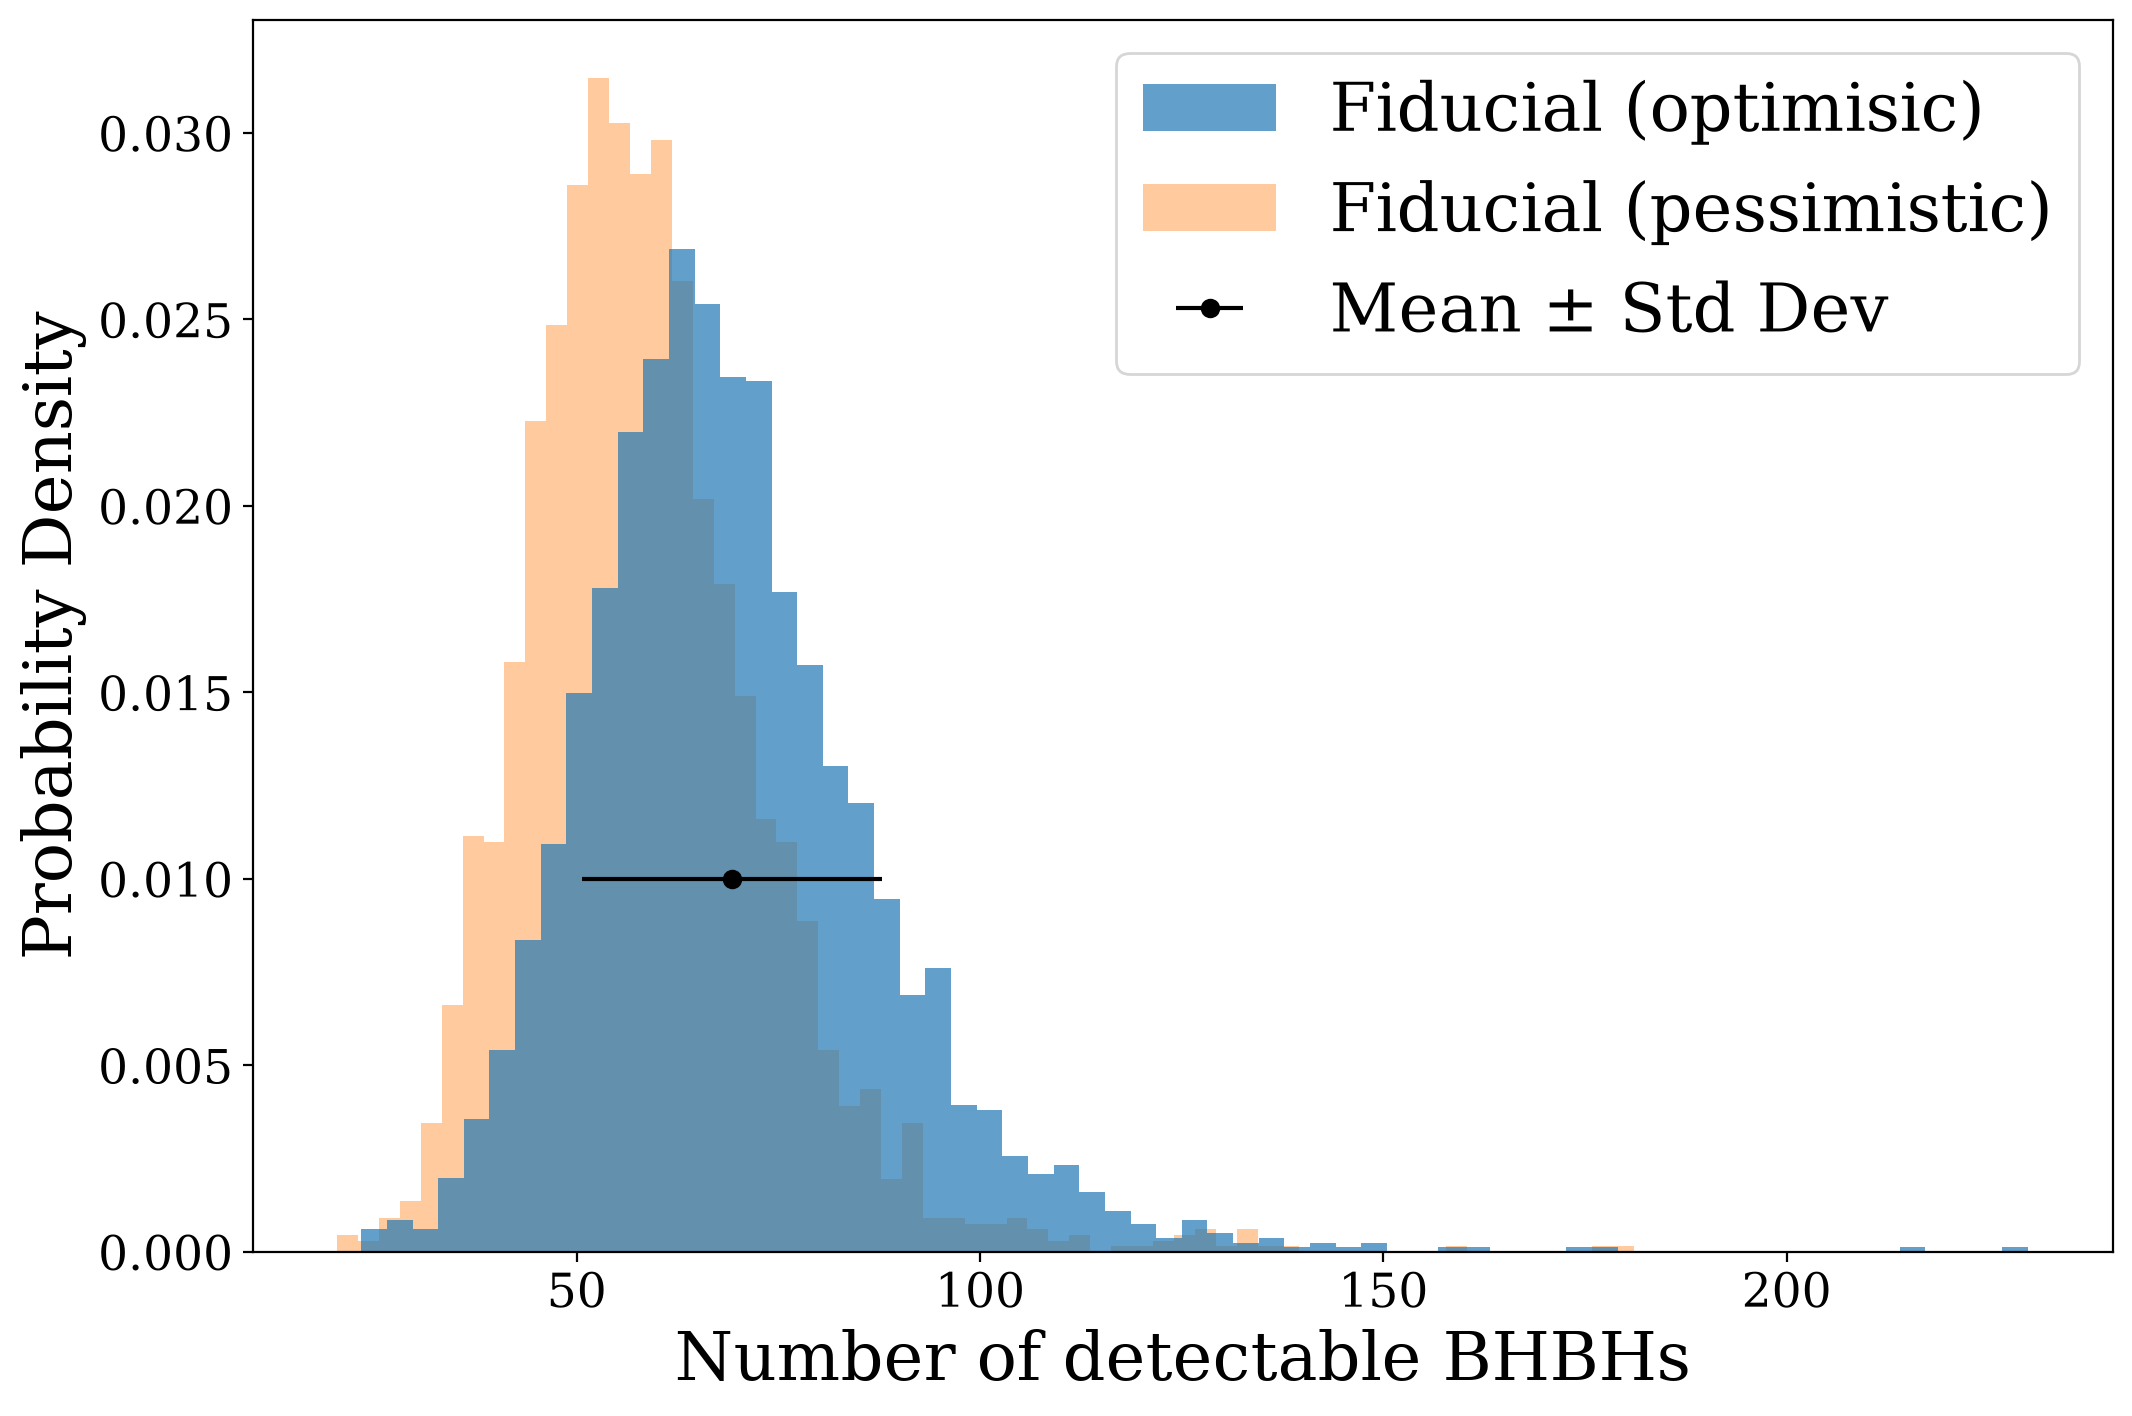

In [38]:
plt.hist(f_detect * n_targets.loc["fiducial"]["BHBH"], bins="auto", alpha=0.7, label="Fiducial (optimisic)", density=True)
plt.hist(f_detect_pess * n_targets.loc["fiducial"]["BHBH_pessimistic"], bins="auto", alpha=0.4, zorder=-1, label="Fiducial (pessimistic)", density=True)
plt.errorbar(np.mean(f_detect) * n_targets.loc["fiducial"]["BHBH"], 0.01, xerr=np.std(f_detect) * n_targets.loc["fiducial"]["BHBH"], fmt="o", color="k", label="Mean ± Std Dev")
# plt.xticks([0, 25, 50, 75, 100])
plt.xlabel("Number of detectable BHBHs")
plt.ylabel("Probability Density")
plt.legend()

In [8]:
sources = pop.to_legwork_sources(assume_mw_galactocentric=True)
sources.evolve_sources(t_evol=pop.initial_galaxy.tau)
sources.get_snr()

array([  6.82061705, 116.16171608,  50.04097621, ...,  10.80337593,
         9.6040721 ,  14.66685673], shape=(69740,))

# Spatial plots

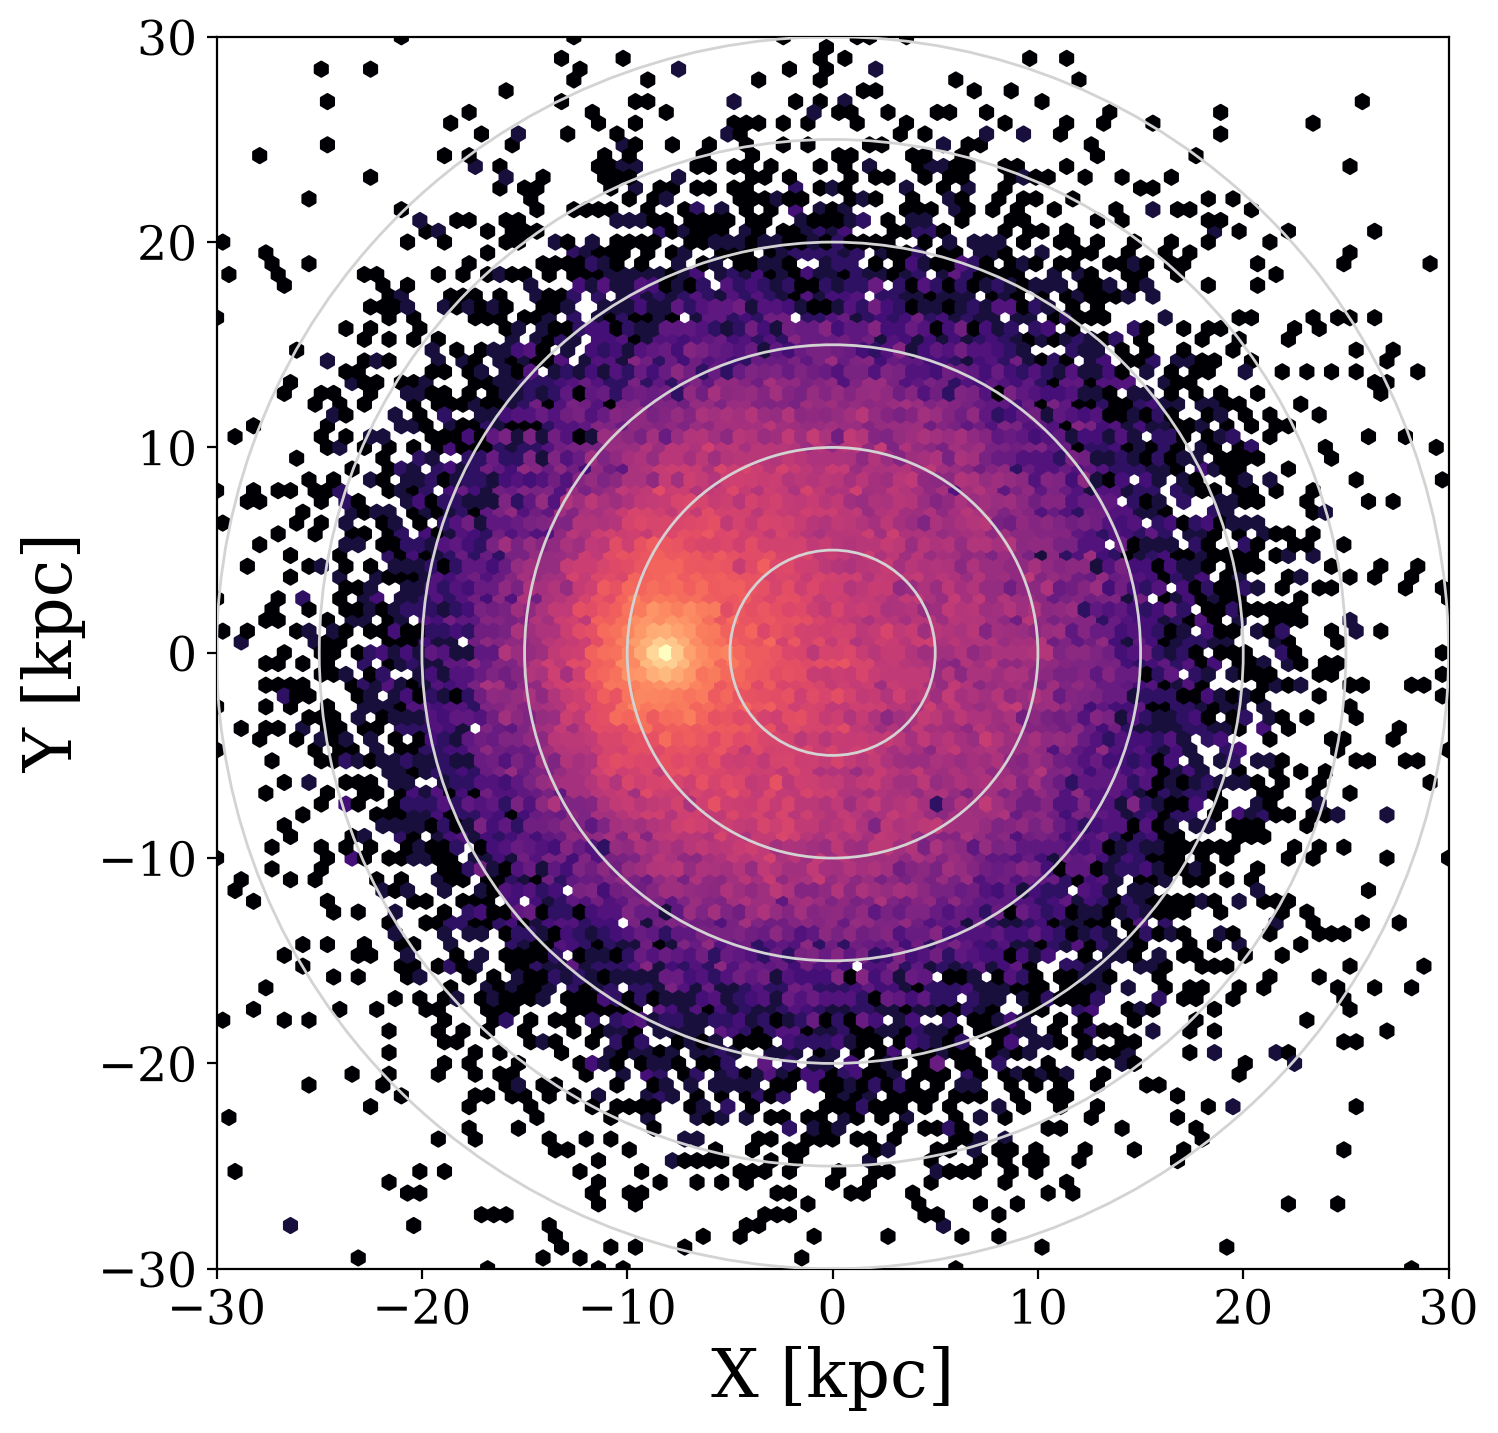

In [10]:
fig, ax = plt.subplots()
ax.hexbin(
    pop.final_pos[:, 0], pop.final_pos[:, 1], extent=(-30, 30, -30, 30), bins="log", gridsize=100, cmap="magma"
)

radii = [5, 10, 15, 20, 25, 30]
for r in radii:
    circle = plt.Circle((0, 0), r, color="lightgrey", fill=False, zorder=10)
    ax.add_artist(circle)

ax.set(
    xlim=(-30, 30), ylim=(-30, 30), xlabel="X [kpc]", ylabel="Y [kpc]",
    aspect="equal"
)
plt.show()

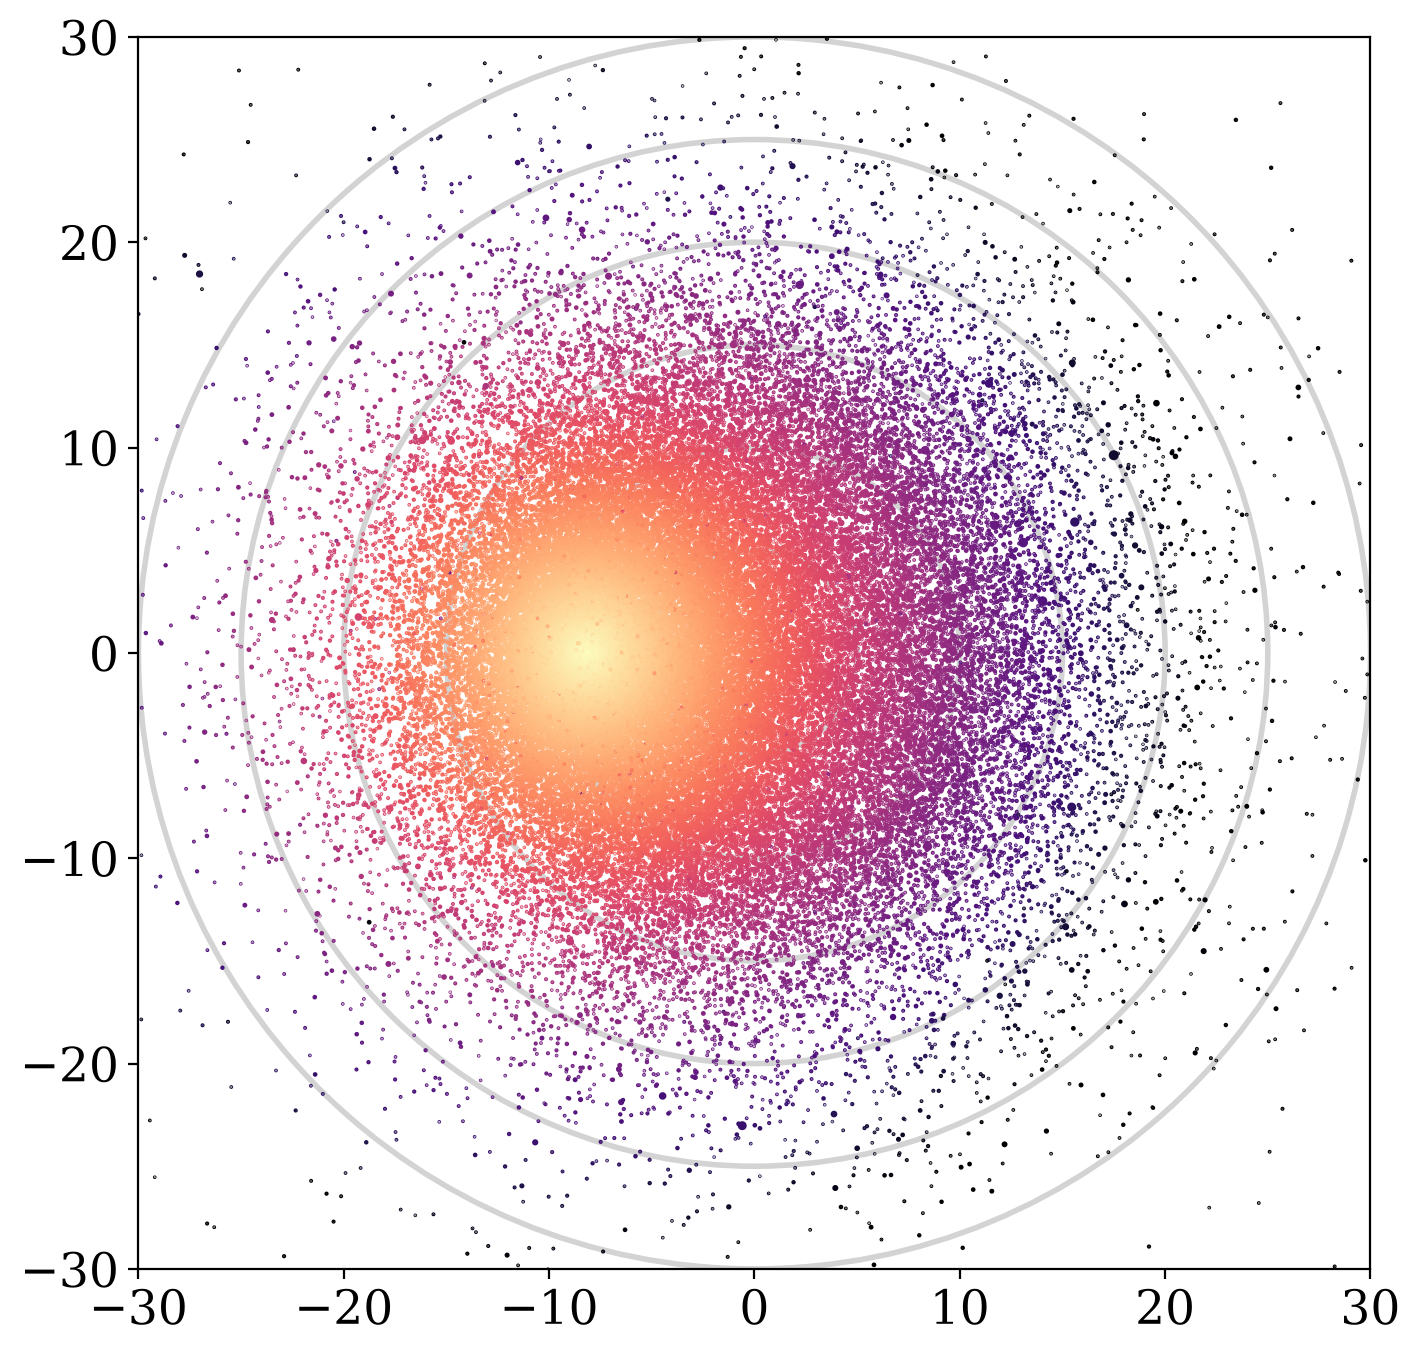

In [11]:
plt.scatter(pop.final_pos[:, 0], pop.final_pos[:, 1], s=5 * pop.initC["weights"], alpha=1, c=np.linalg.norm(pop.final_pos - [-8.2, 0, 0] * u.kpc, axis=1), cmap="magma_r", vmin=0, vmax=30, rasterized=True)

# add circles of constant radius, 1, 5, 10, 15, 20, 25, 30 kpc
radii = [5, 10, 15, 20, 25, 30]
for r in radii:
    circle = plt.Circle((0, 0), r, color="lightgrey", fill=False, zorder=-1, lw=2)
    plt.gca().add_artist(circle)

plt.xlim(-30, 30)
plt.ylim(-30, 30)
plt.gca().set_aspect("equal")

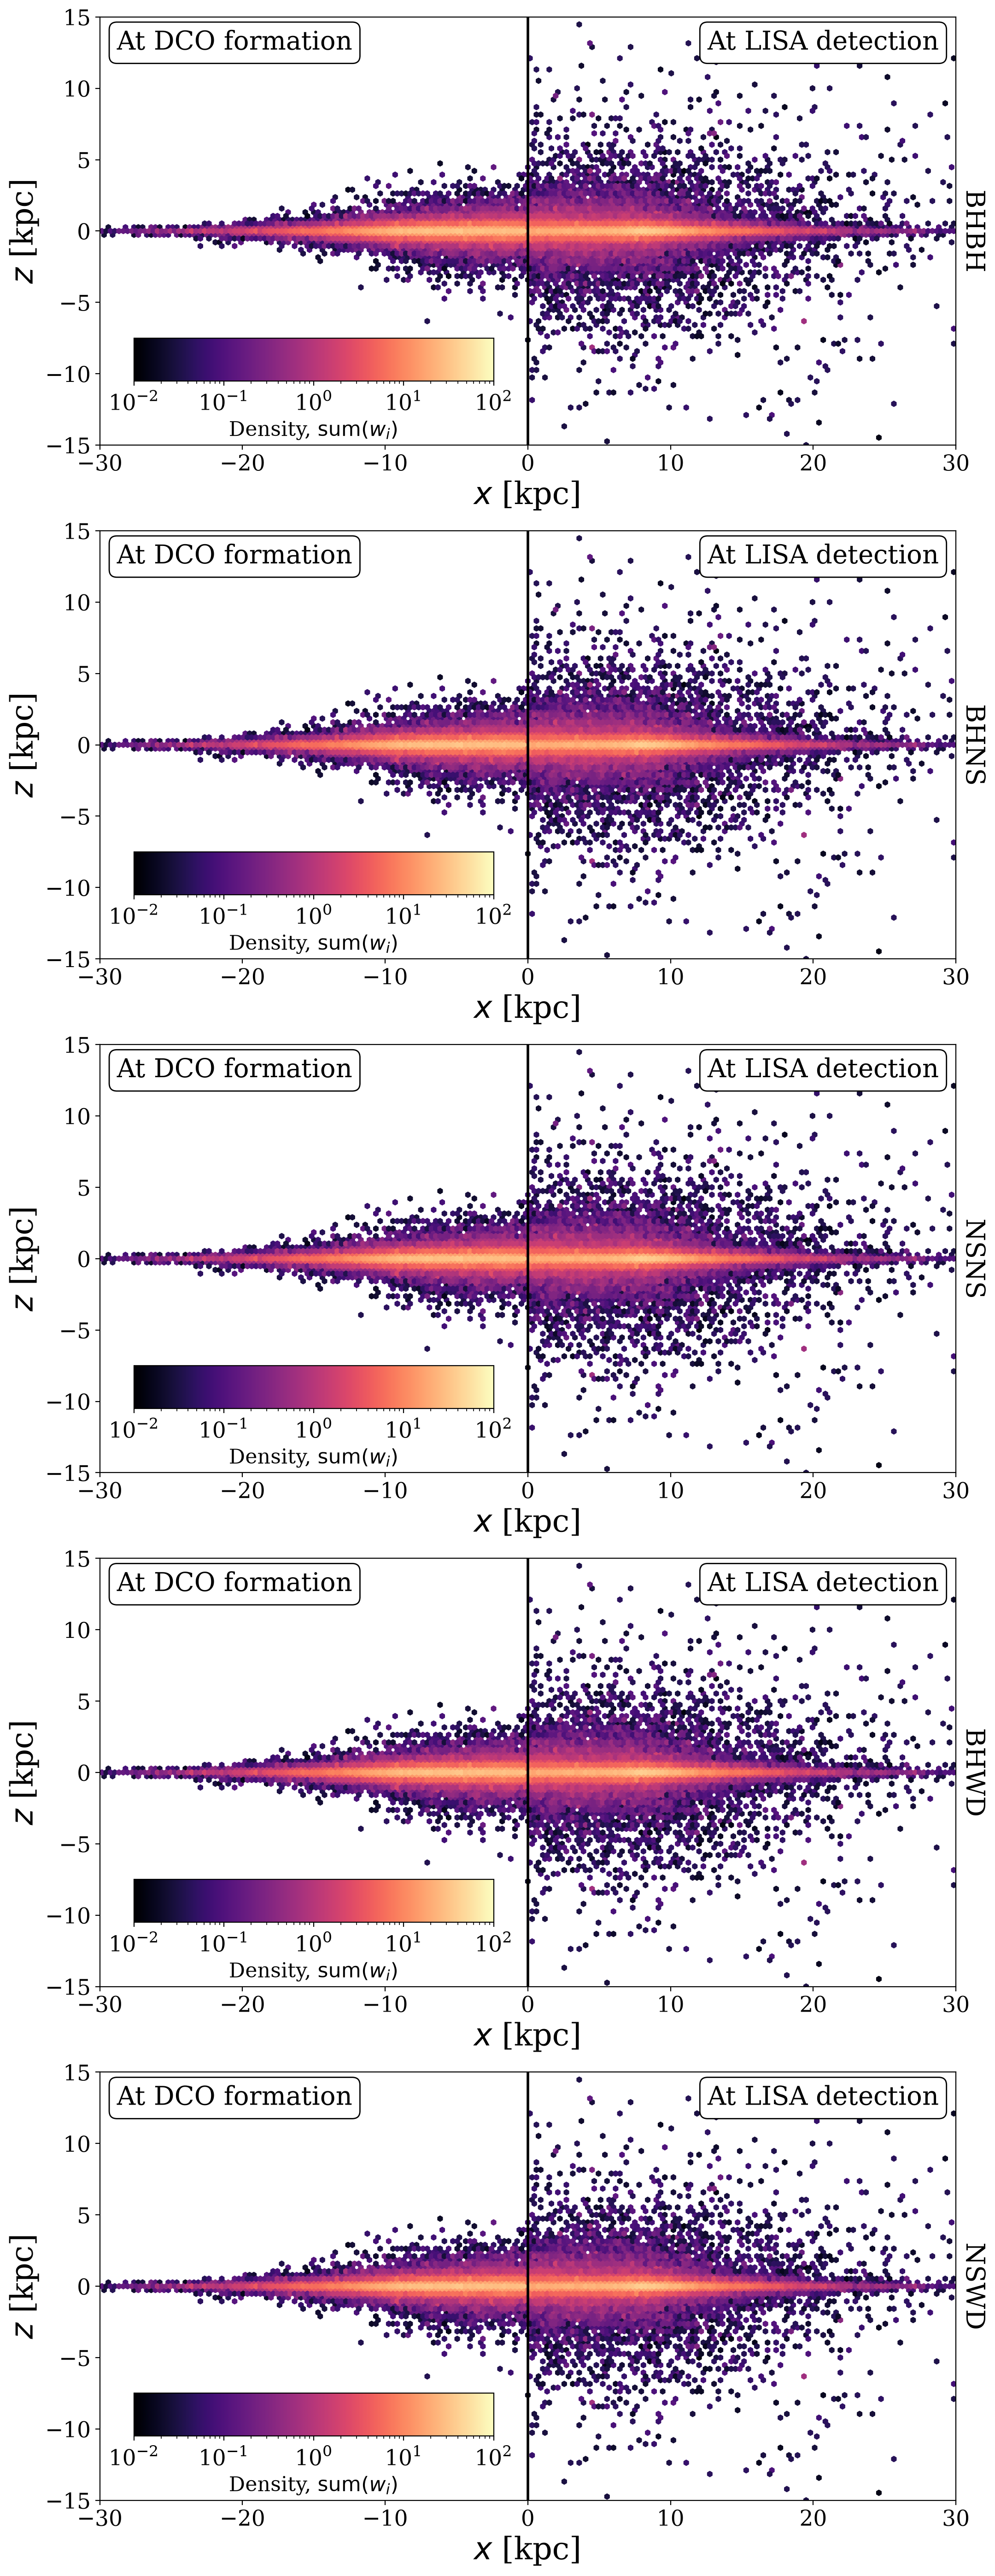

In [13]:
fig, axes = plt.subplots(5, 1, figsize=(14, 35))

ax = axes[0]

for ax, dco_type in zip(axes, ["BHBH", "BHNS", "NSNS", "BHWD", "NSWD"]):

    for x, z, extent in zip([-np.abs(pop.initial_galaxy.x), np.abs(pop.final_pos[:, 0])], [pop.initial_galaxy.z, pop.final_pos[:, 2]], [(-30, 0, -15, 15), (0, 30, -15, 15)]):
        hexbin = ax.hexbin(x, z, C=pop.initC["weights"].values, reduce_C_function=np.sum, extent=extent, vmin=1e-2, vmax=1e2, bins="log", cmap="magma")

    inset_ax = ax.inset_axes([0.04, 0.15, 0.42, 0.1])

    ax.axvline(0, color="k", ls="-", lw=2)

    cbar = fig.colorbar(hexbin, orientation="horizontal", cax=inset_ax)
    cbar.set_label(r"Density, ${\rm sum}(w_i)$", fontsize=16)

    ax.annotate("At DCO formation", xy=(0.02, 0.97), xycoords="axes fraction", va="top", bbox=dict(boxstyle="round", facecolor="white"), fontsize=20)
    ax.annotate("At LISA detection", xy=(0.98, 0.97), xycoords="axes fraction", ha='right', va="top", bbox=dict(boxstyle="round", facecolor="white"), fontsize=20)

    ax.annotate(dco_type, xy=(1.02, 0.5), xycoords="axes fraction", ha='center', va="center", fontsize=20, rotation=270)

    ax.set(
        xlabel=r"$x$ [kpc]", ylabel=r"$z$ [kpc]", xlim=(-30, 30), ylim=(-15, 15), aspect="equal"
    )

plt.show()

In [2]:
fig, axes = plt.subplots(5, 1, figsize=(14, 35))

ax = axes[0]

for ax, dco_type in zip(axes, ["BHBH", "BHNS", "NSNS", "BHWD", "NSWD"]):

    for x, z, extent in zip([-np.abs(pop.initial_galaxy.x), np.abs(pop.final_pos[:, 0])], [pop.initial_galaxy.z, pop.final_pos[:, 2]], [(-30, 0, -15, 15), (0, 30, -15, 15)]):
        hexbin = ax.hexbin(x, z, C=pop.initC["weights"].values, reduce_C_function=np.sum, extent=extent, cmap="magma")

    inset_ax = ax.inset_axes([0.04, 0.15, 0.42, 0.1])

    ax.axvline(0, color="k", ls="-", lw=2)

    cbar = fig.colorbar(hexbin, orientation="horizontal", cax=inset_ax)
    cbar.set_label(r"Density, ${\rm sum}(w_i)$", fontsize=16)

    ax.annotate("At DCO formation", xy=(0.02, 0.97), xycoords="axes fraction", va="top", bbox=dict(boxstyle="round", facecolor="white"), fontsize=20)
    ax.annotate("At LISA detection", xy=(0.98, 0.97), xycoords="axes fraction", ha='right', va="top", bbox=dict(boxstyle="round", facecolor="white"), fontsize=20)

    ax.annotate(dco_type, xy=(1.02, 0.5), xycoords="axes fraction", ha='center', va="center", fontsize=20, rotation=270)

    ax.set(
        xlabel=r"$x$ [kpc]", ylabel=r"$z$ [kpc]", xlim=(-30, 30), ylim=(-15, 15), aspect="equal"
    )

plt.show()

NameError: name 'plt' is not defined

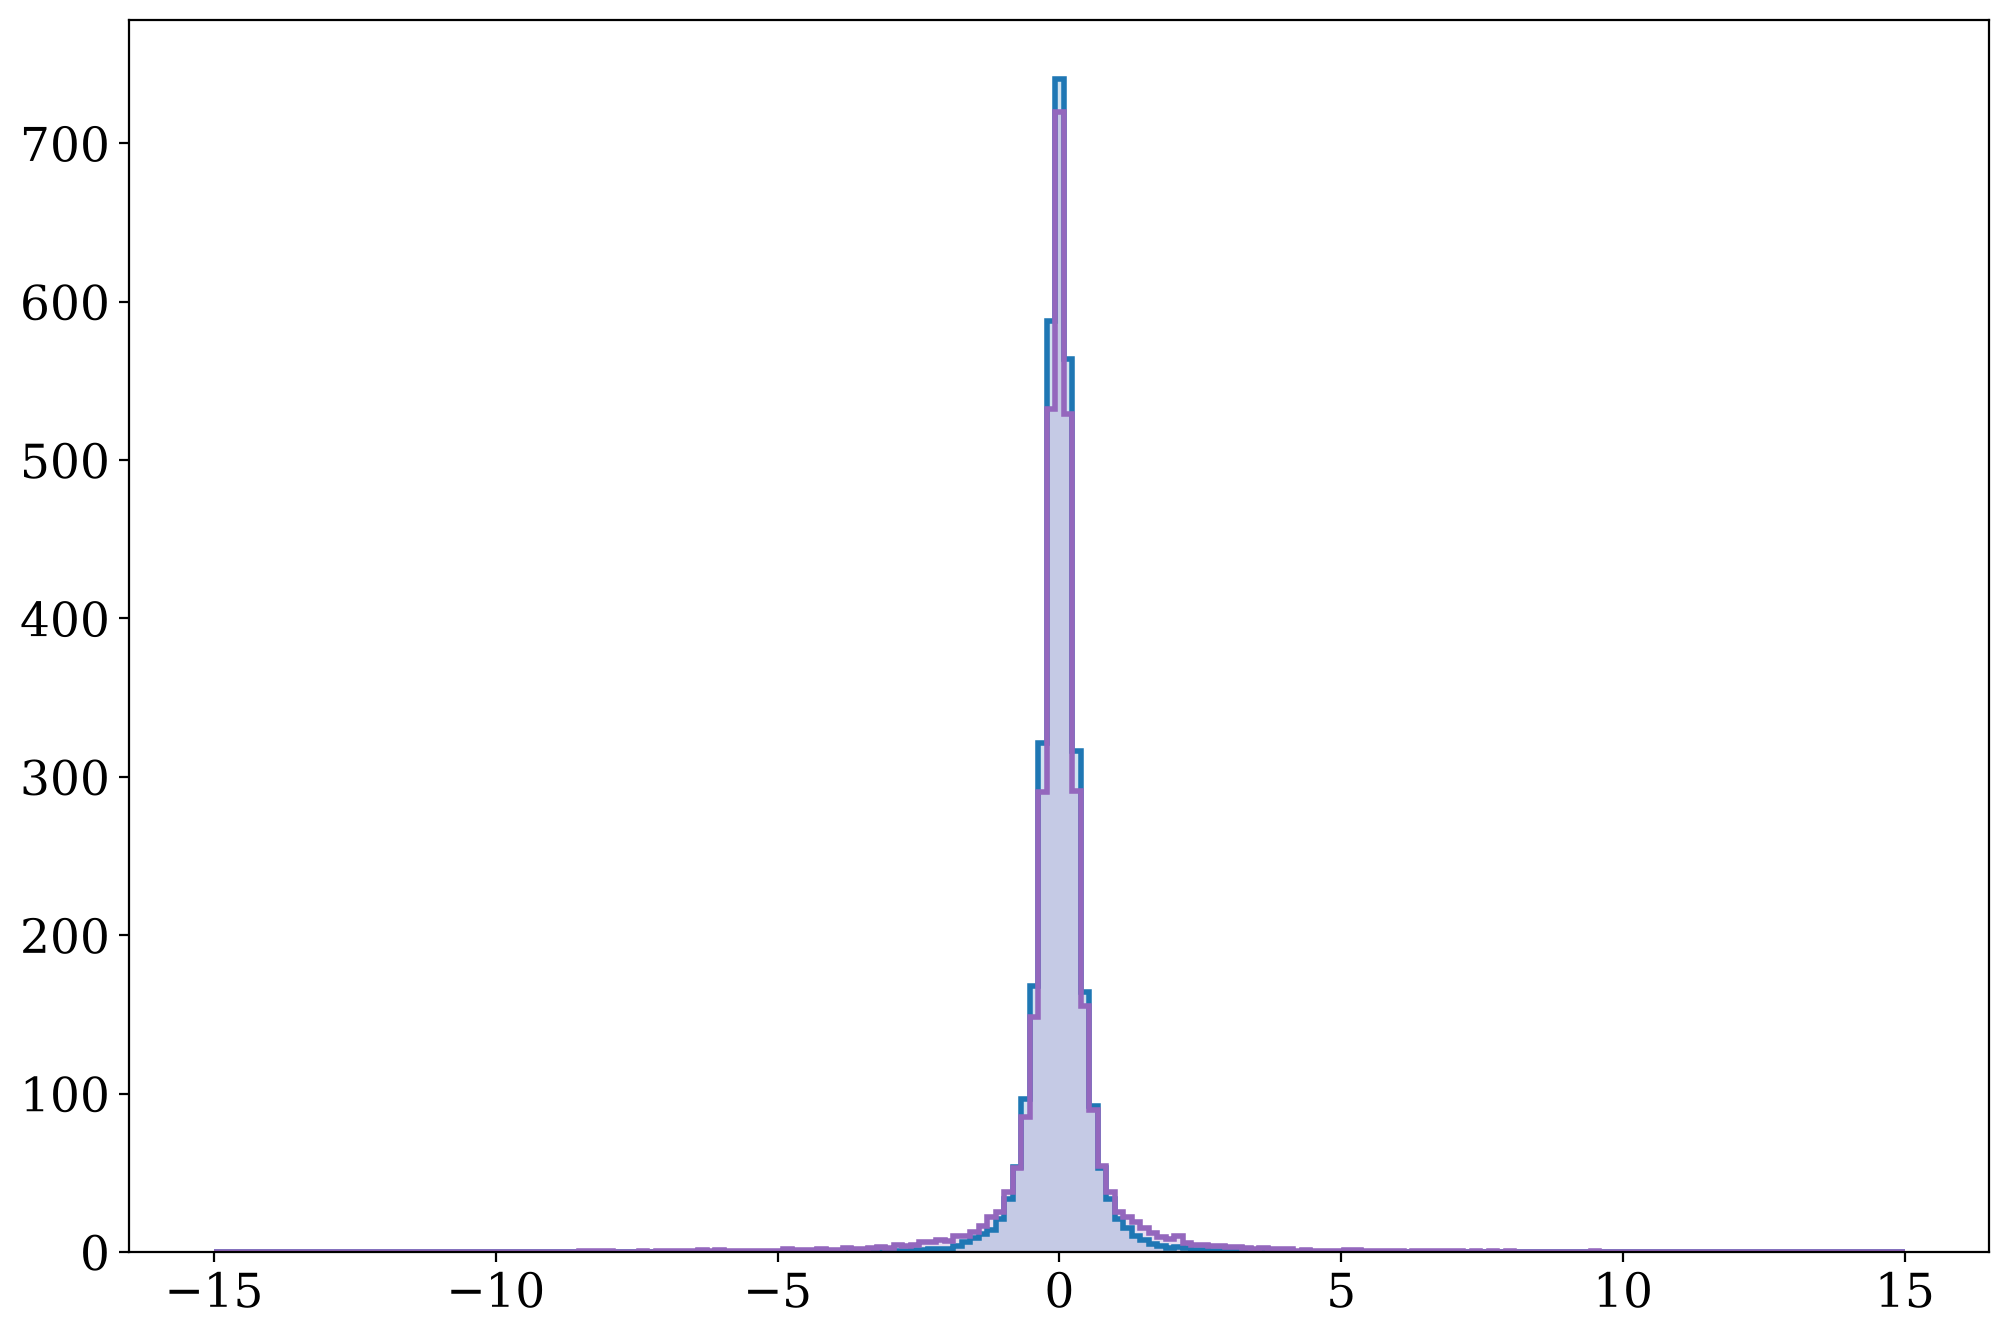

In [14]:
bins = np.linspace(-15, 15, 200)

plt.hist(pop.initial_galaxy.z.value, weights=pop.initC["weights"], bins=bins, histtype="step", lw=2);
plt.hist(pop.final_pos[:, 2].value, weights=pop.initC["weights"], bins=bins, histtype="step", lw=2, color="C4");
plt.hist(pop.initial_galaxy.z.value, weights=pop.initC["weights"], bins=bins, alpha=0.2, color="C0");
plt.hist(pop.final_pos[:, 2].value, weights=pop.initC["weights"], bins=bins, alpha=0.2, color="C4");
# plt.yscale("log")

# LISA source plots

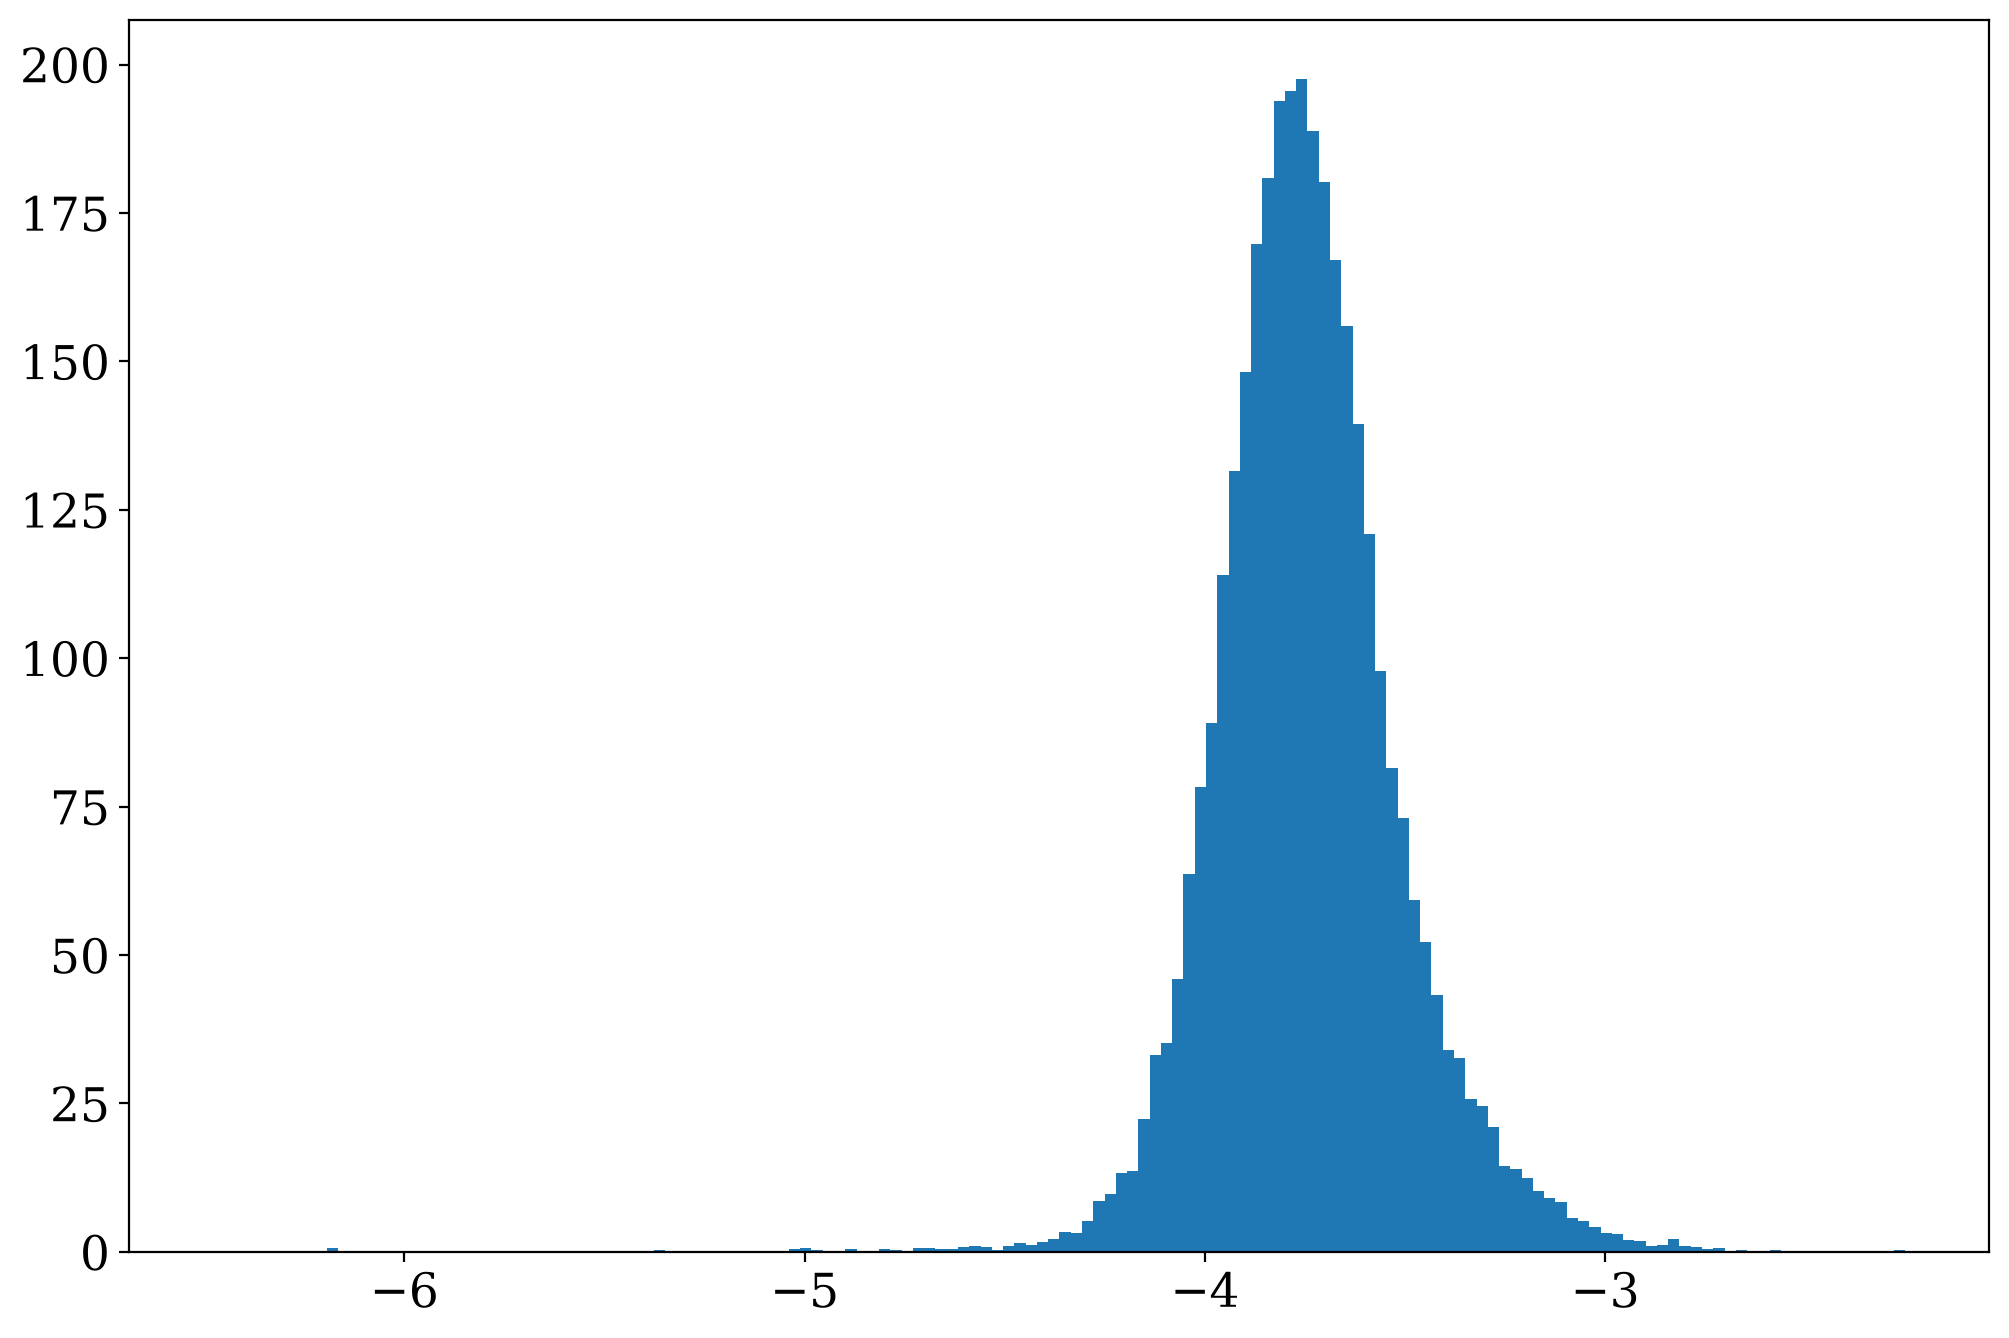

In [15]:
plt.hist(np.log10(sources.f_orb.value), weights=pop.initC["weights"], bins=150);

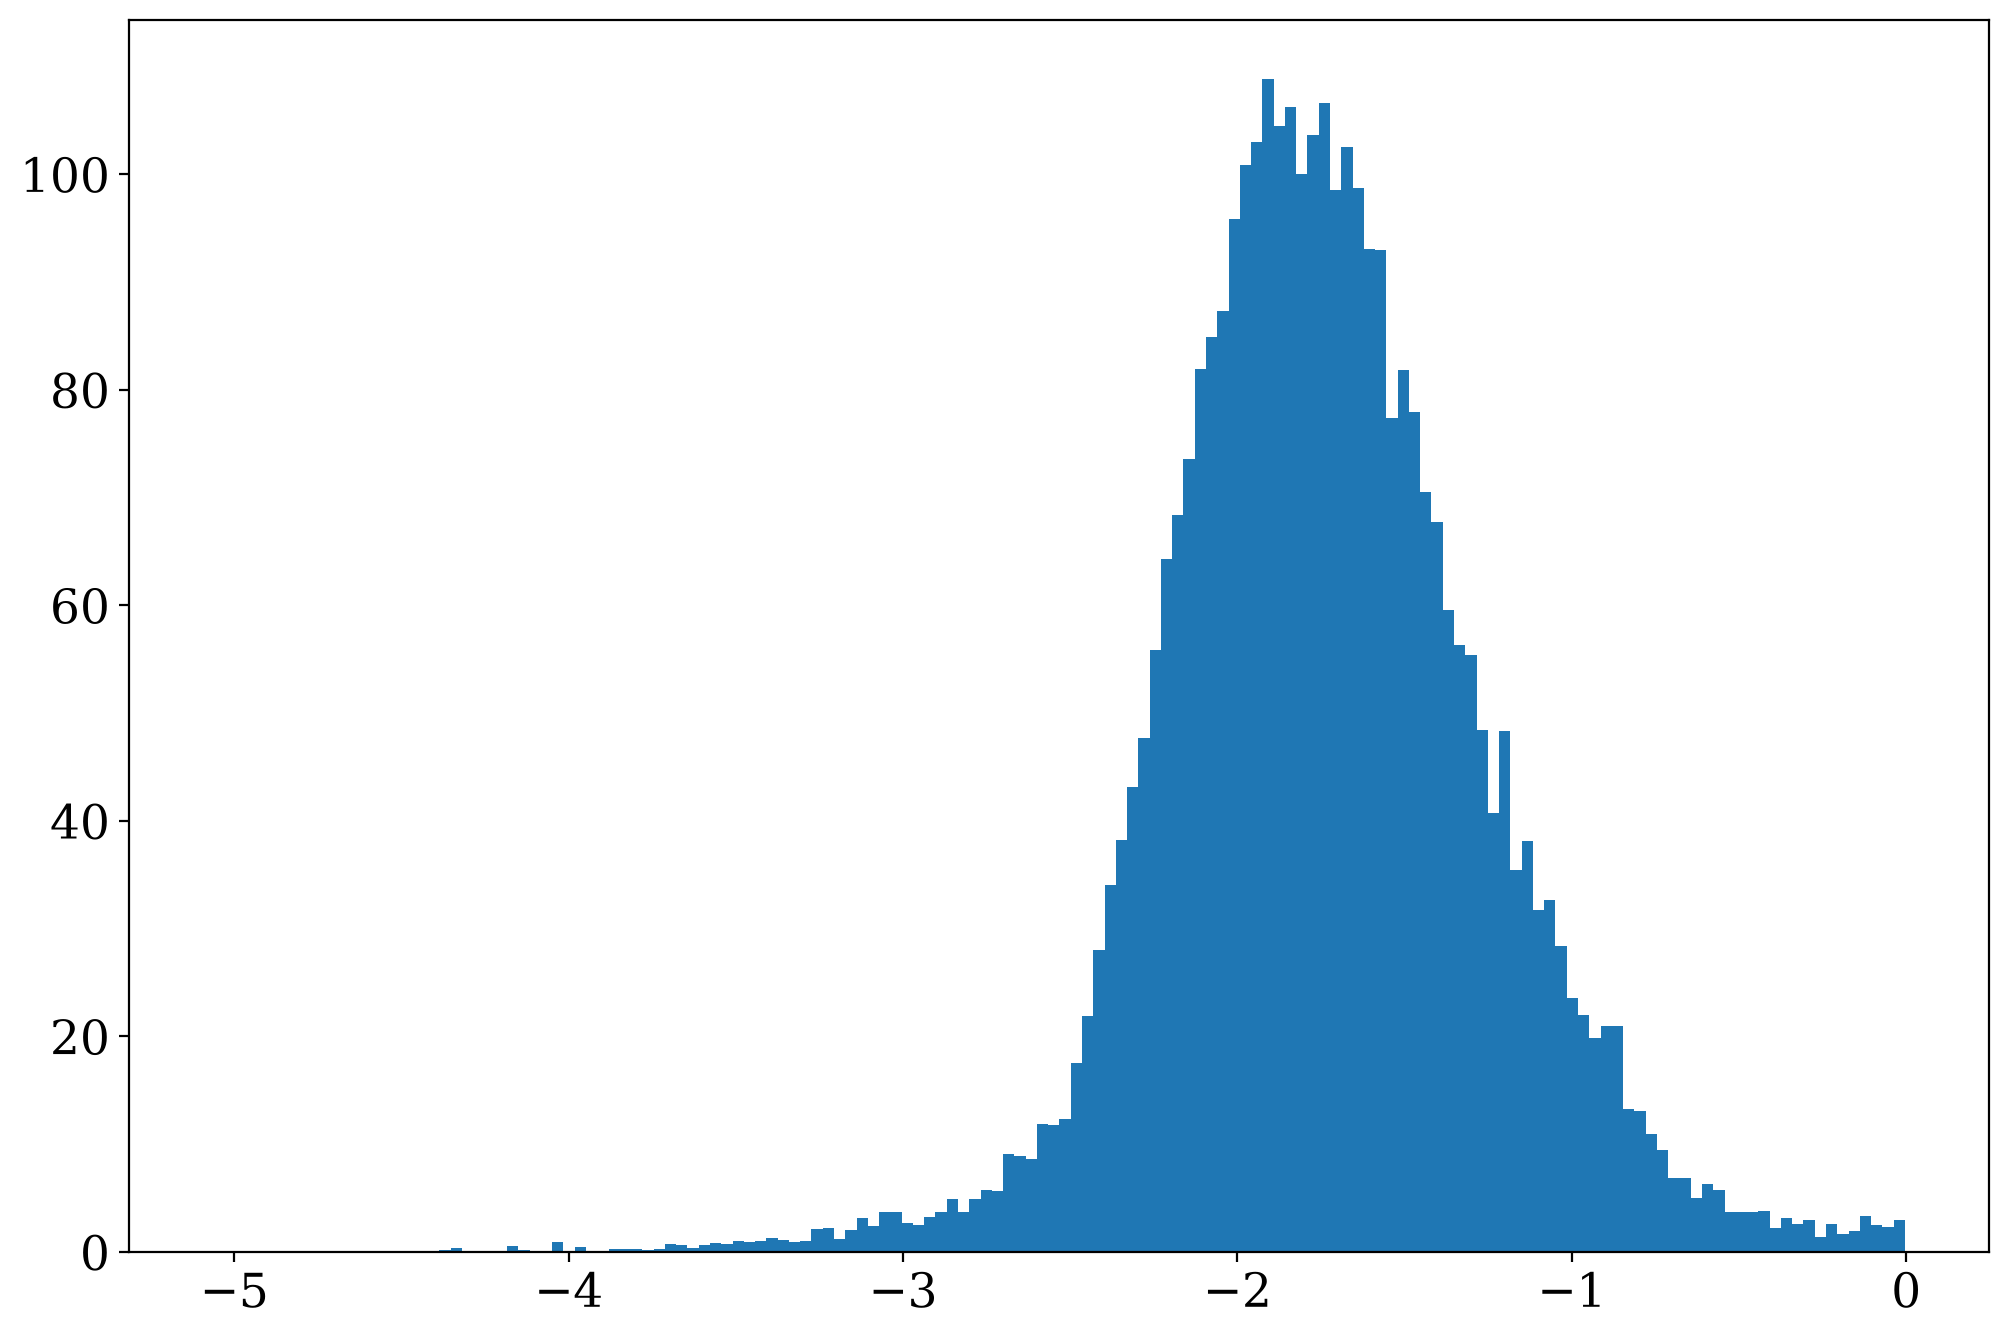

In [16]:
plt.hist(np.log10(sources.ecc), weights=pop.initC["weights"], bins=150);

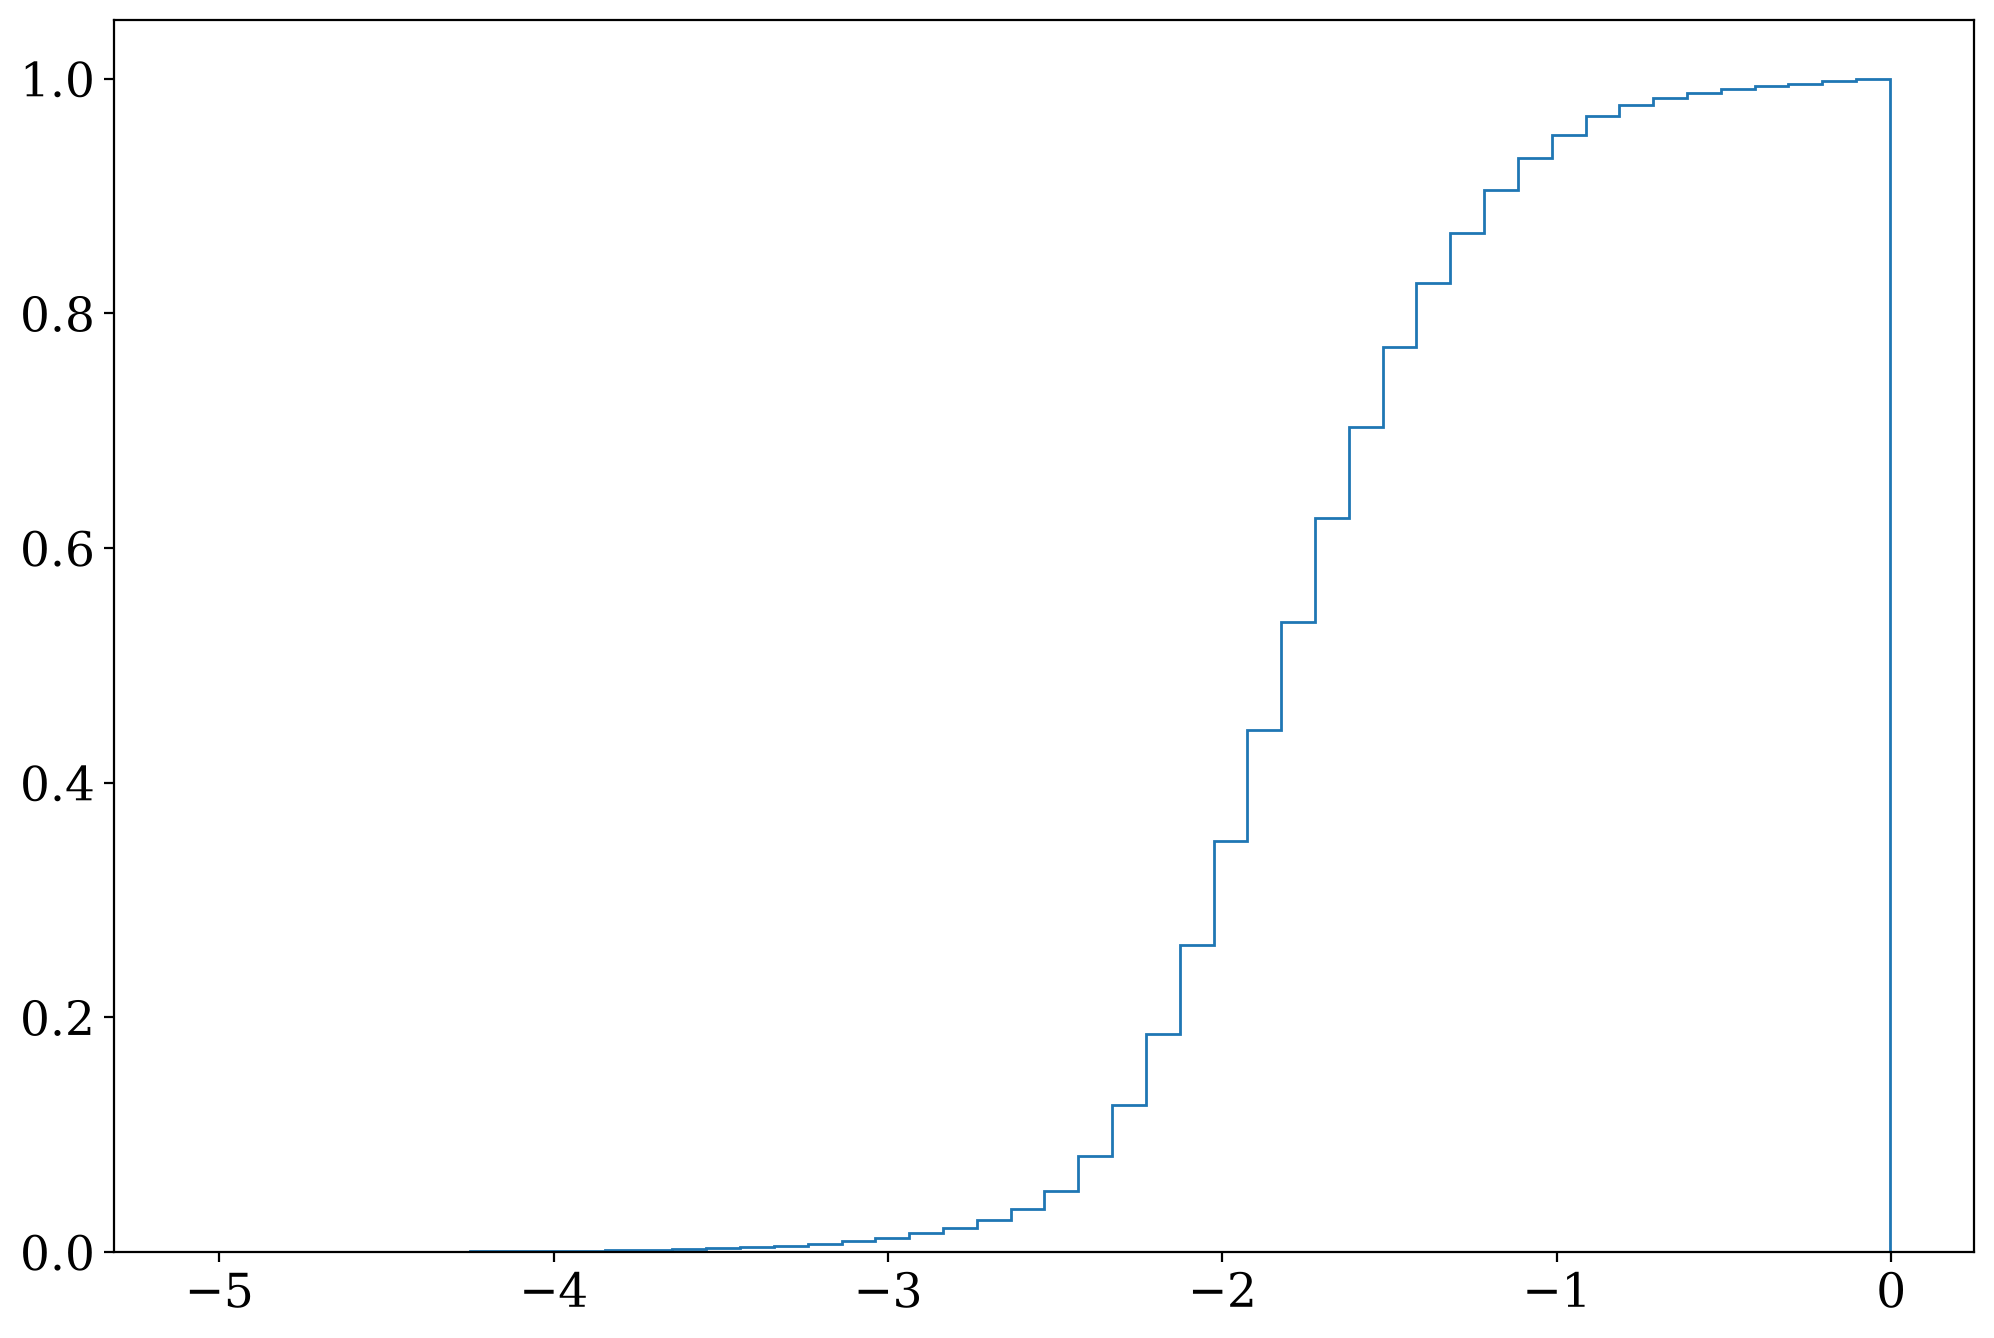

In [17]:
plt.hist(np.log10(sources.ecc), weights=pop.initC["weights"], bins=50, cumulative=True, density=True, histtype="step", label="Cumulative Distribution");

# Uncertainties

In [44]:
import uncertainties as unc
snr_uncertainty, snr_ratio, detectable_harmonics, max_harmonics = unc.get_ecc_uncertainty_stats(sources, harmonic_threshold=2)
min_ratio = np.clip(snr_ratio - snr_uncertainty, 0, None)

<Quantity [3.01077984e-10, 4.28239543e-10, 5.90191278e-10, ...,
           1.65532423e-11, 9.67761943e-12, 1.54332084e-11] Hz / yr>

In [73]:
sigma_m_c = unc.get_m_c_uncertainty(
    sources.f_orb,
    lw.utils.fn_dot(sources.m_c, sources.f_orb, sources.ecc, n=1),
    sources.ecc,
    snr_uncertainty,
    sources.snr,
    4 * u.yr
)
sky_localisation = unc.sky_localisation(
    sources.snr,
    sources.f_orb * 2,
)

In [54]:
(sigma_m_c < 1).sum() / len(sources)

np.float64(0.2820031144177769)

In [81]:
theta = np.arctan(np.abs(pop.final_pos[:, 2]) / sources.dist).to(u.deg)
sigma_theta = sky_localisation / theta

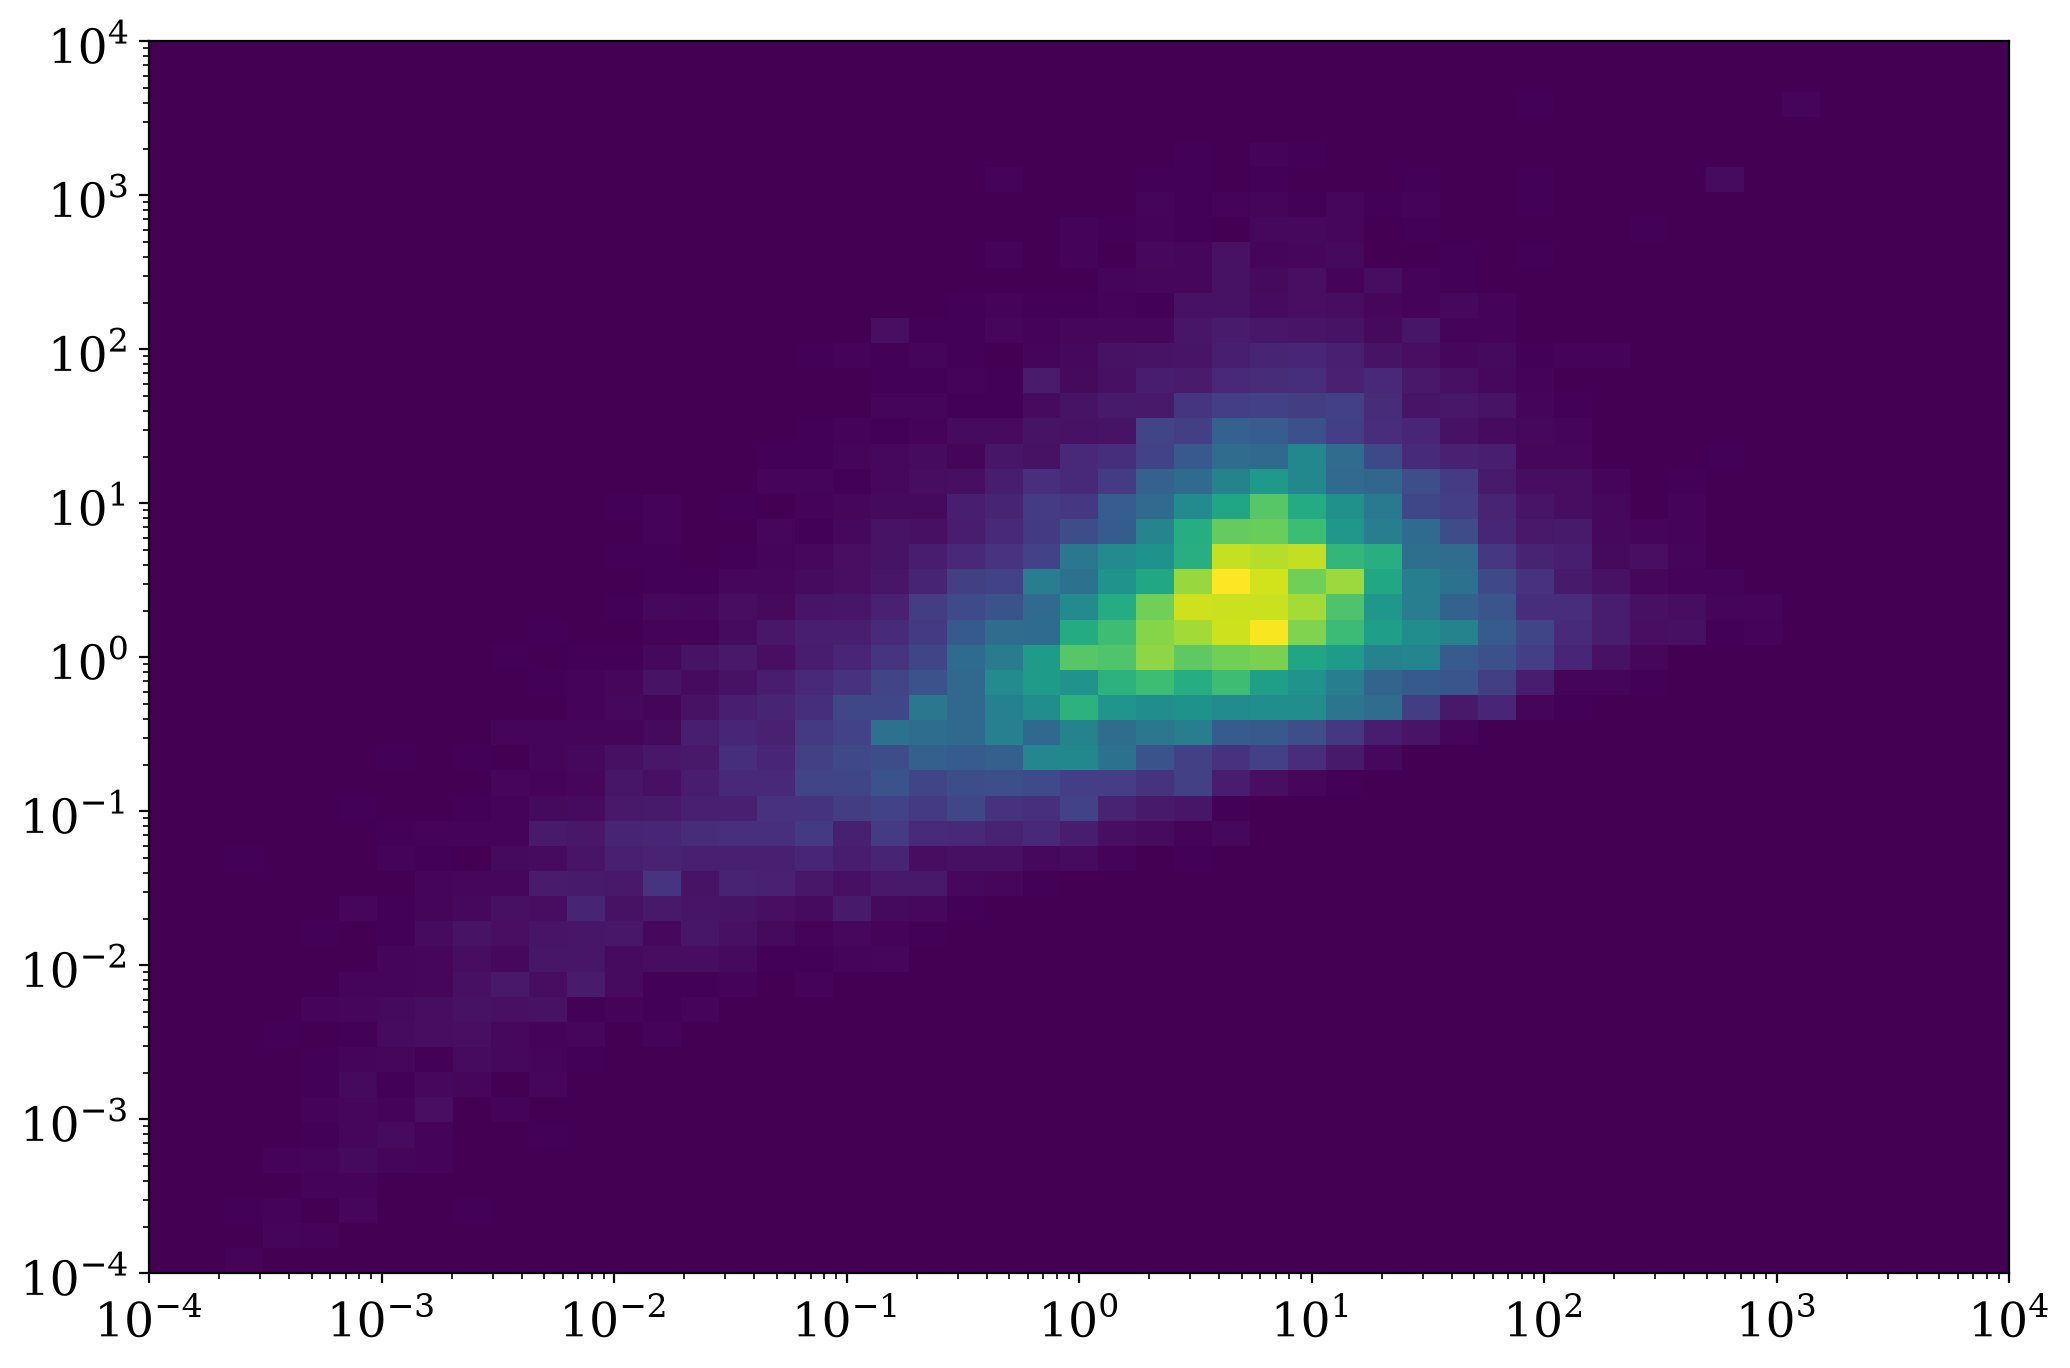

In [109]:
fig, ax = plt.subplots()

# ax.scatter(sigma_m_c, sigma_theta, s=10 * pop.initC["weights"])
ax.hist2d(
    sigma_m_c, sigma_theta, weights=pop.initC["weights"],
    bins=(np.logspace(-4, 4, 50), np.logspace(-4, 4, 50)),
)

ax.set(
    xscale="log", yscale="log"
)

plt.show()

In [92]:
massive = (sources.m_c - sigma_m_c * sources.m_c) > 1.2 * u.Msun
np.sum(pop.initC["weights"][massive]) / np.sum(pop.initC["weights"])

np.float64(0.26309124575862025)

In [93]:
away_from_plane = np.arcsin(1 * u.kpc / sources.dist) - sky_localisation > 0 * u.deg
np.sum(pop.initC["weights"][away_from_plane]) / np.sum(pop.initC["weights"])

/mnt/home/twagg/miniforge3/envs/cogsworth/lib/python3.11/site-packages/astropy/units/quantity.py:659: RuntimeWarning: invalid value encountered in arcsin
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)



np.float64(0.35030998842773653)

[None, None]

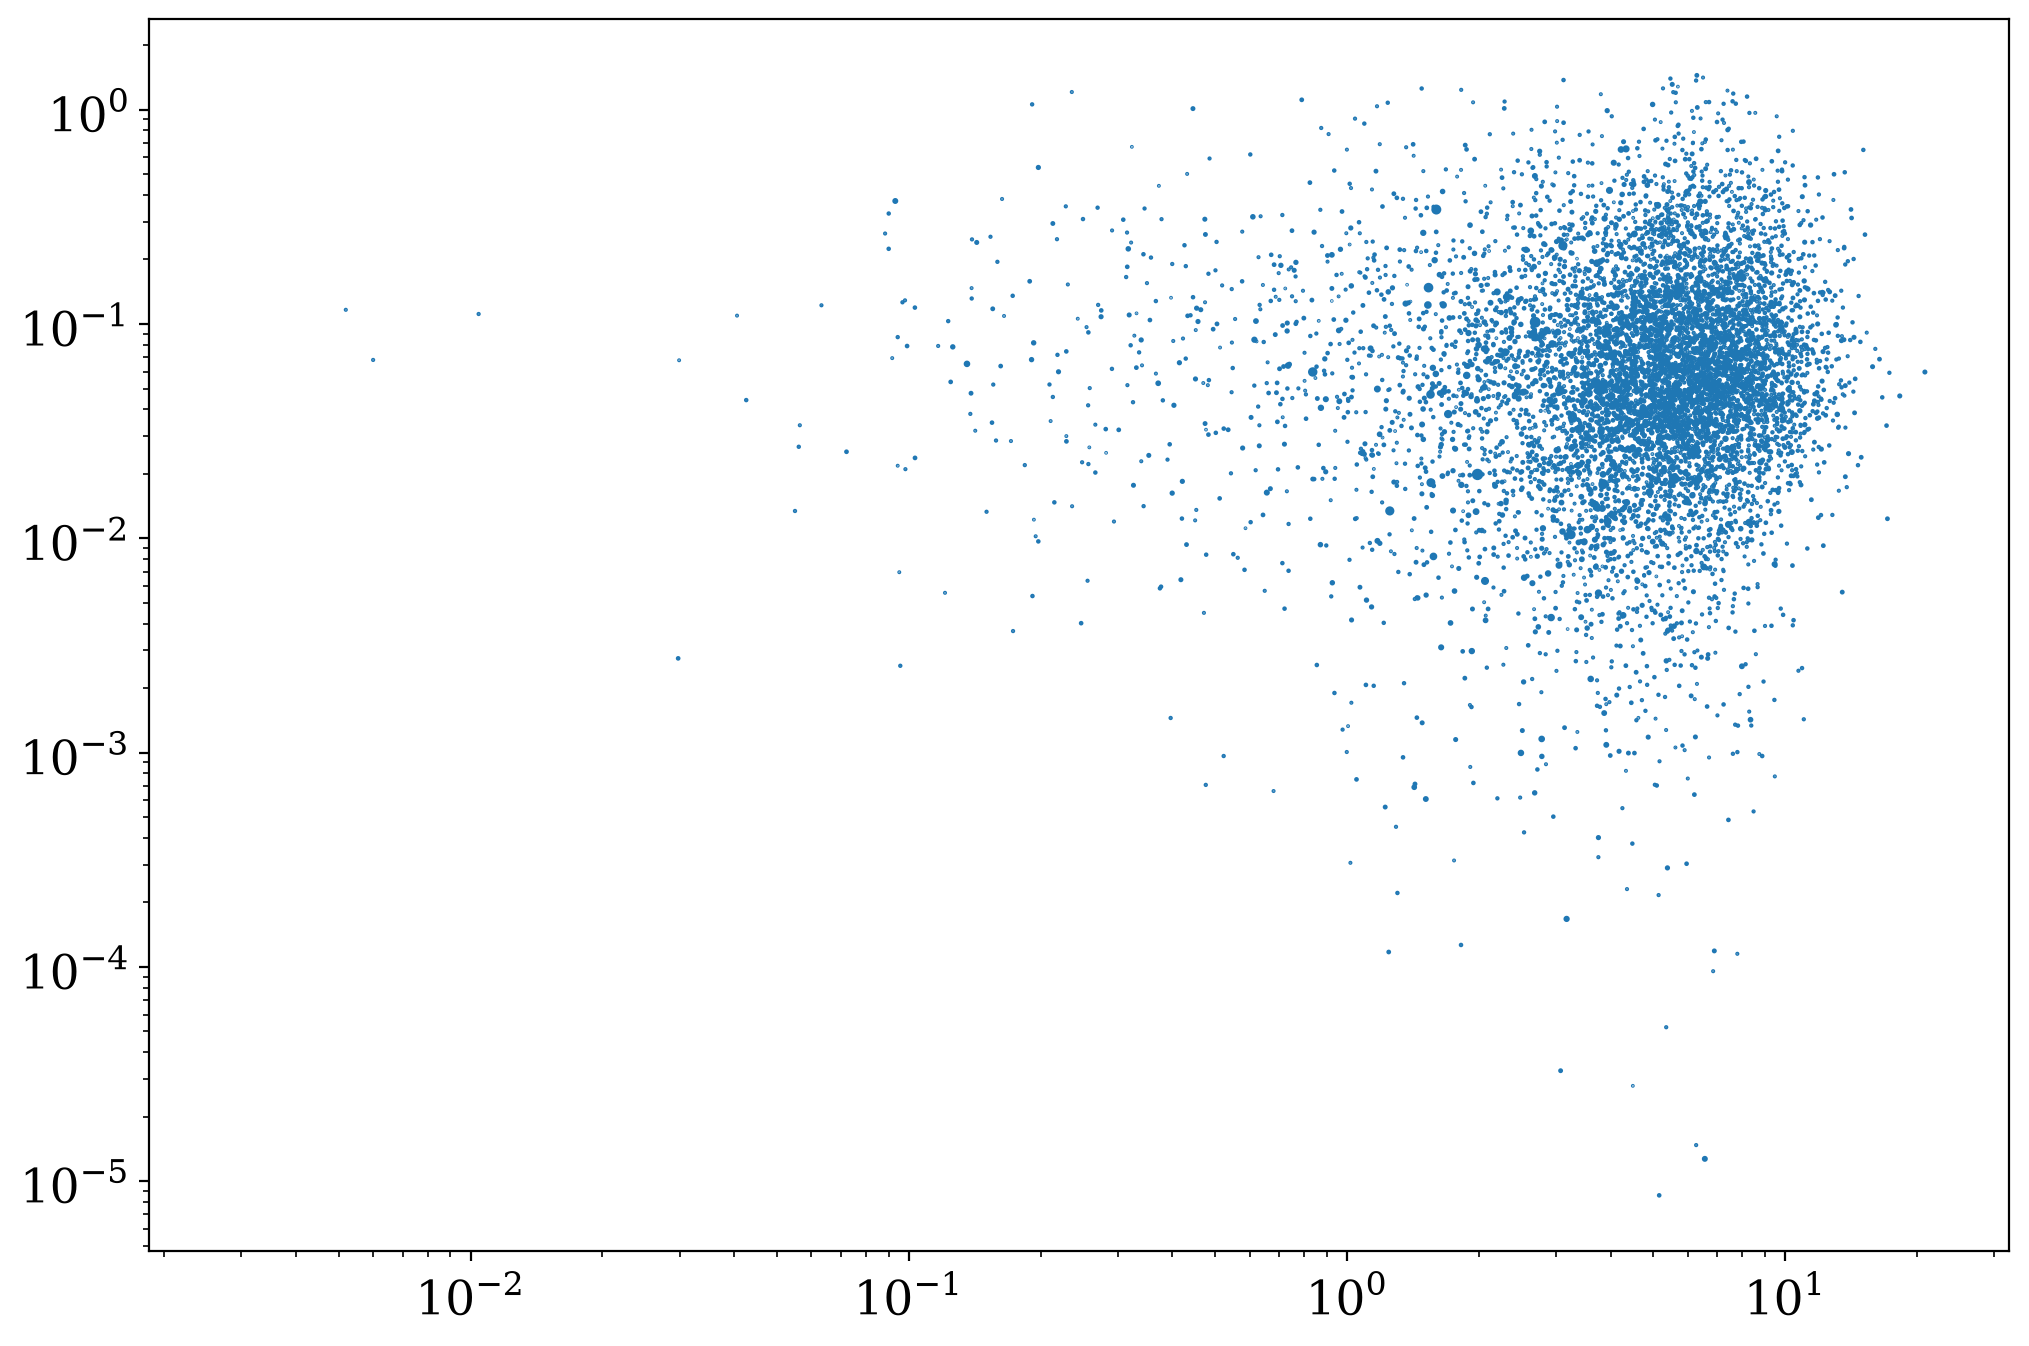

In [94]:
fig, ax = plt.subplots()

ax.scatter(sources.m_c - sigma_m_c * sources.m_c - 1.2 * u.Msun, np.arcsin(1 * u.kpc / sources.dist) - sky_localisation, s=10 * pop.initC["weights"])

ax.set(
    xscale="log", yscale="log"
)

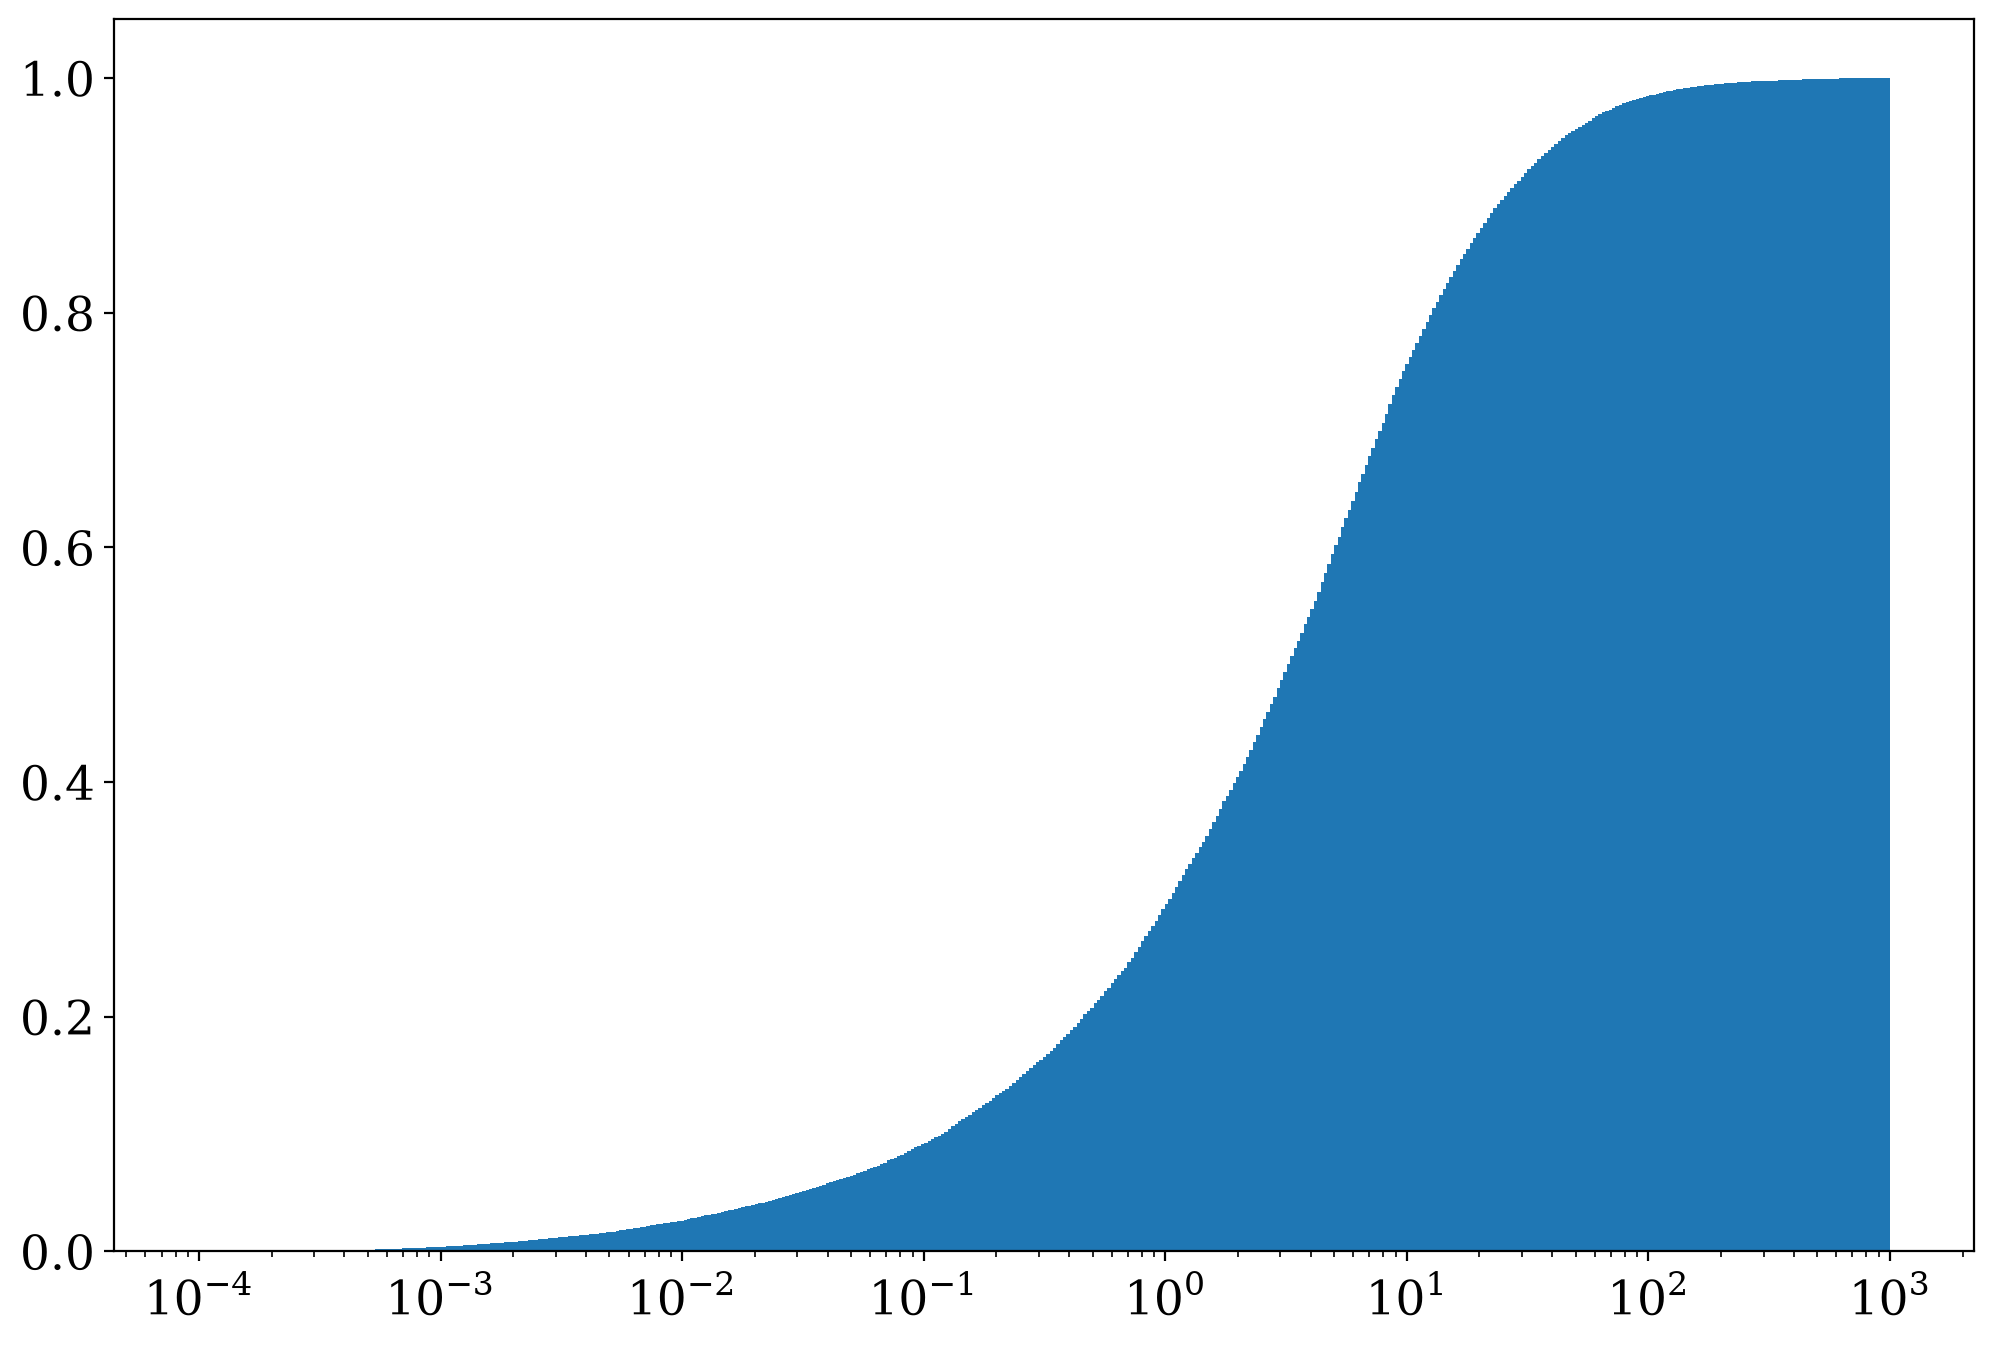

In [56]:
plt.hist(sigma_m_c, cumulative=True, bins=np.logspace(-4, 3, 500), density=True, weights=pop.initC["weights"])
plt.xscale("log")

In [45]:
ranges = [(0, 1), (1e-3, 1), (0.01, 1), (0.1, 1)]
for lo, hi in ranges:
    in_range = min_ratio[(min_ratio >= lo) & (min_ratio <= hi)]
    in_range_dh = detectable_harmonics[(min_ratio >= lo) & (min_ratio <= hi)]
    in_range_weights = pop.initC["weights"][(min_ratio >= lo) & (min_ratio <= hi)]
    print(np.sum(in_range_weights[((in_range > 1e-2) & (in_range_dh >= 2))]) / np.sum(in_range_weights) * 100)

2.348066994123517
94.6580839559977
100.0
100.0


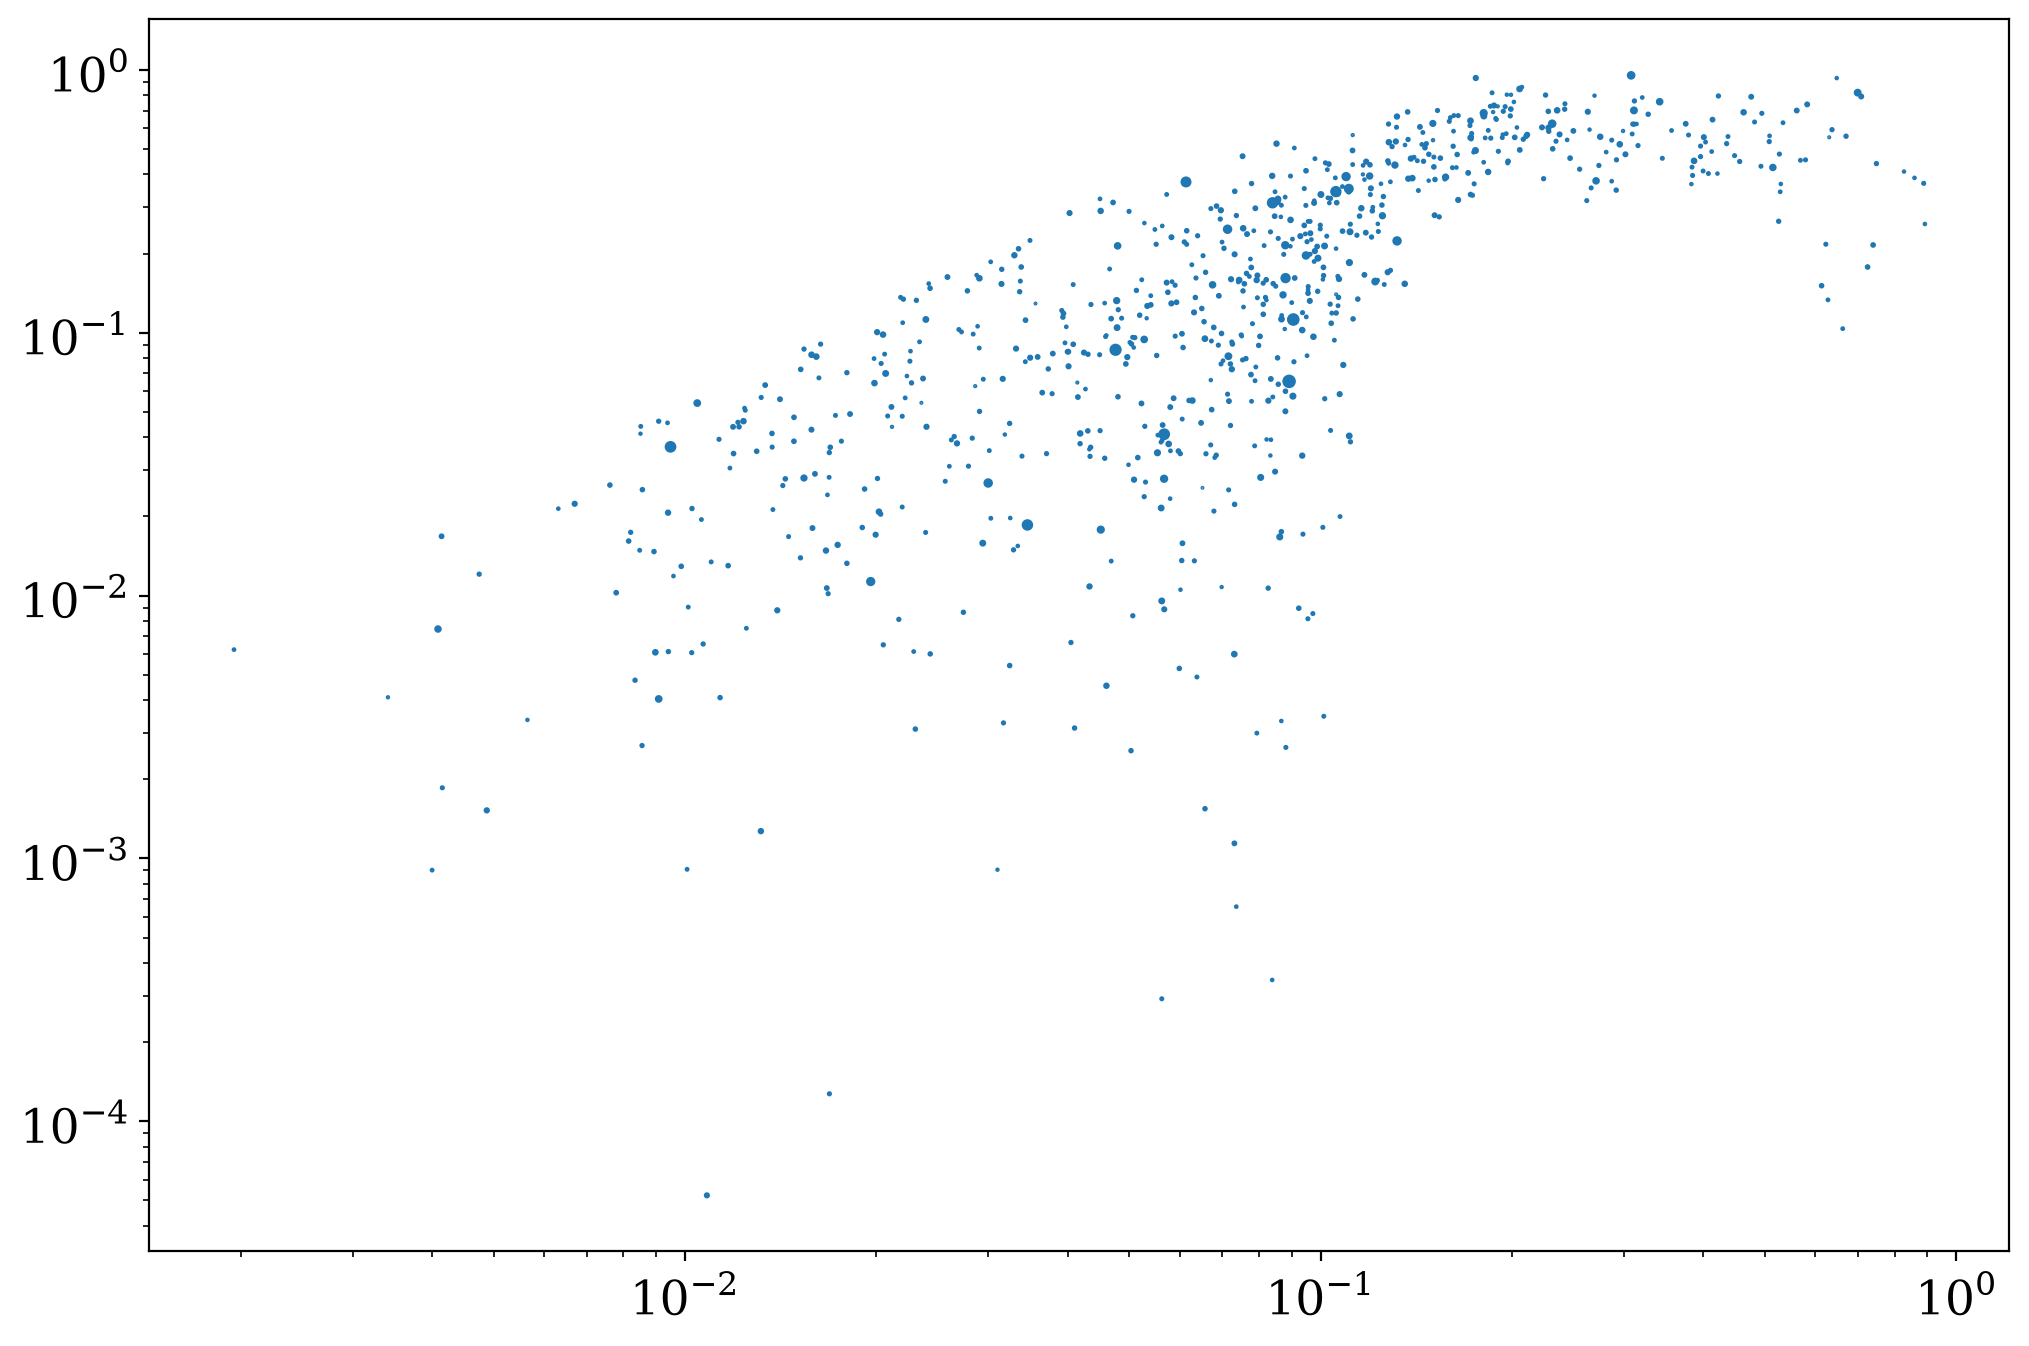

In [157]:
plt.scatter(sources.ecc[min_ratio > 0], min_ratio[min_ratio > 0], s=20 * pop.initC["weights"][min_ratio > 0])
plt.xscale("log")
plt.yscale("log")

In [133]:
snr_ratio - snr_uncertainty > 0.01

array([False, False, False, ..., False, False, False], shape=(40457,))

In [130]:
snr_uncertainty

array([2.00081009, 0.67625843, 0.48317602, ..., 1.15830565, 0.90784628,
       2.5251525 ], shape=(40457,))

In [122]:
np.unique(detectable_harmonics, return_counts=True)

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  18,  20,  21,  24,  25,  26,  29,  30,  31,
         32,  34,  35,  38,  39,  40,  77,  86,  94, 104, 111, 119, 122,
        438]),
 array([    4, 26397, 13387,   423,   102,    35,    18,    14,    13,
           21,     1,     1,     1,     1,     2,     3,     2,     3,
            4,     1,     1,     2,     2,     1,     1,     1,     1,
            2,     1,     1,     1,     1,     1,     1,     1,     1,
            1,     1,     2,     1]))

(array([1.51398157e+03, 2.00997843e+02, 4.33131828e+01, 1.57982183e+01,
        9.42439195e+00, 3.98070171e+00, 1.95968241e+00, 1.15113174e+00,
        1.40141247e+00, 7.82763234e-01, 4.63015850e-01, 7.91387956e-01,
        2.86779855e-01, 3.59012173e-01, 3.28290460e-01, 6.28128792e-01,
        2.28431397e-01, 2.70199173e-02, 2.74214888e-01, 2.35491963e-01,
        1.50444793e-01, 1.05450229e-01, 1.31183932e-01, 9.46356100e-02,
        1.34117795e-01, 2.70476790e-01, 2.87050995e-02, 9.25865902e-02,
        9.86890548e-02, 1.15166773e-01, 1.26995257e-01, 1.96843180e-01,
        7.08816876e-02, 7.05811872e-02, 2.35135248e-01, 1.56670347e-01,
        9.65398553e-02, 3.48772758e-02, 0.00000000e+00, 0.00000000e+00,
        1.99241923e-01, 0.00000000e+00, 2.23142217e-02, 2.82655911e-01,
        3.60970219e-01, 0.00000000e+00, 0.00000000e+00, 6.31949301e-01,
        1.74192475e-01]),
 array([0.        , 0.02040816, 0.04081633, 0.06122449, 0.08163265,
        0.10204082, 0.12244898, 0.14285714

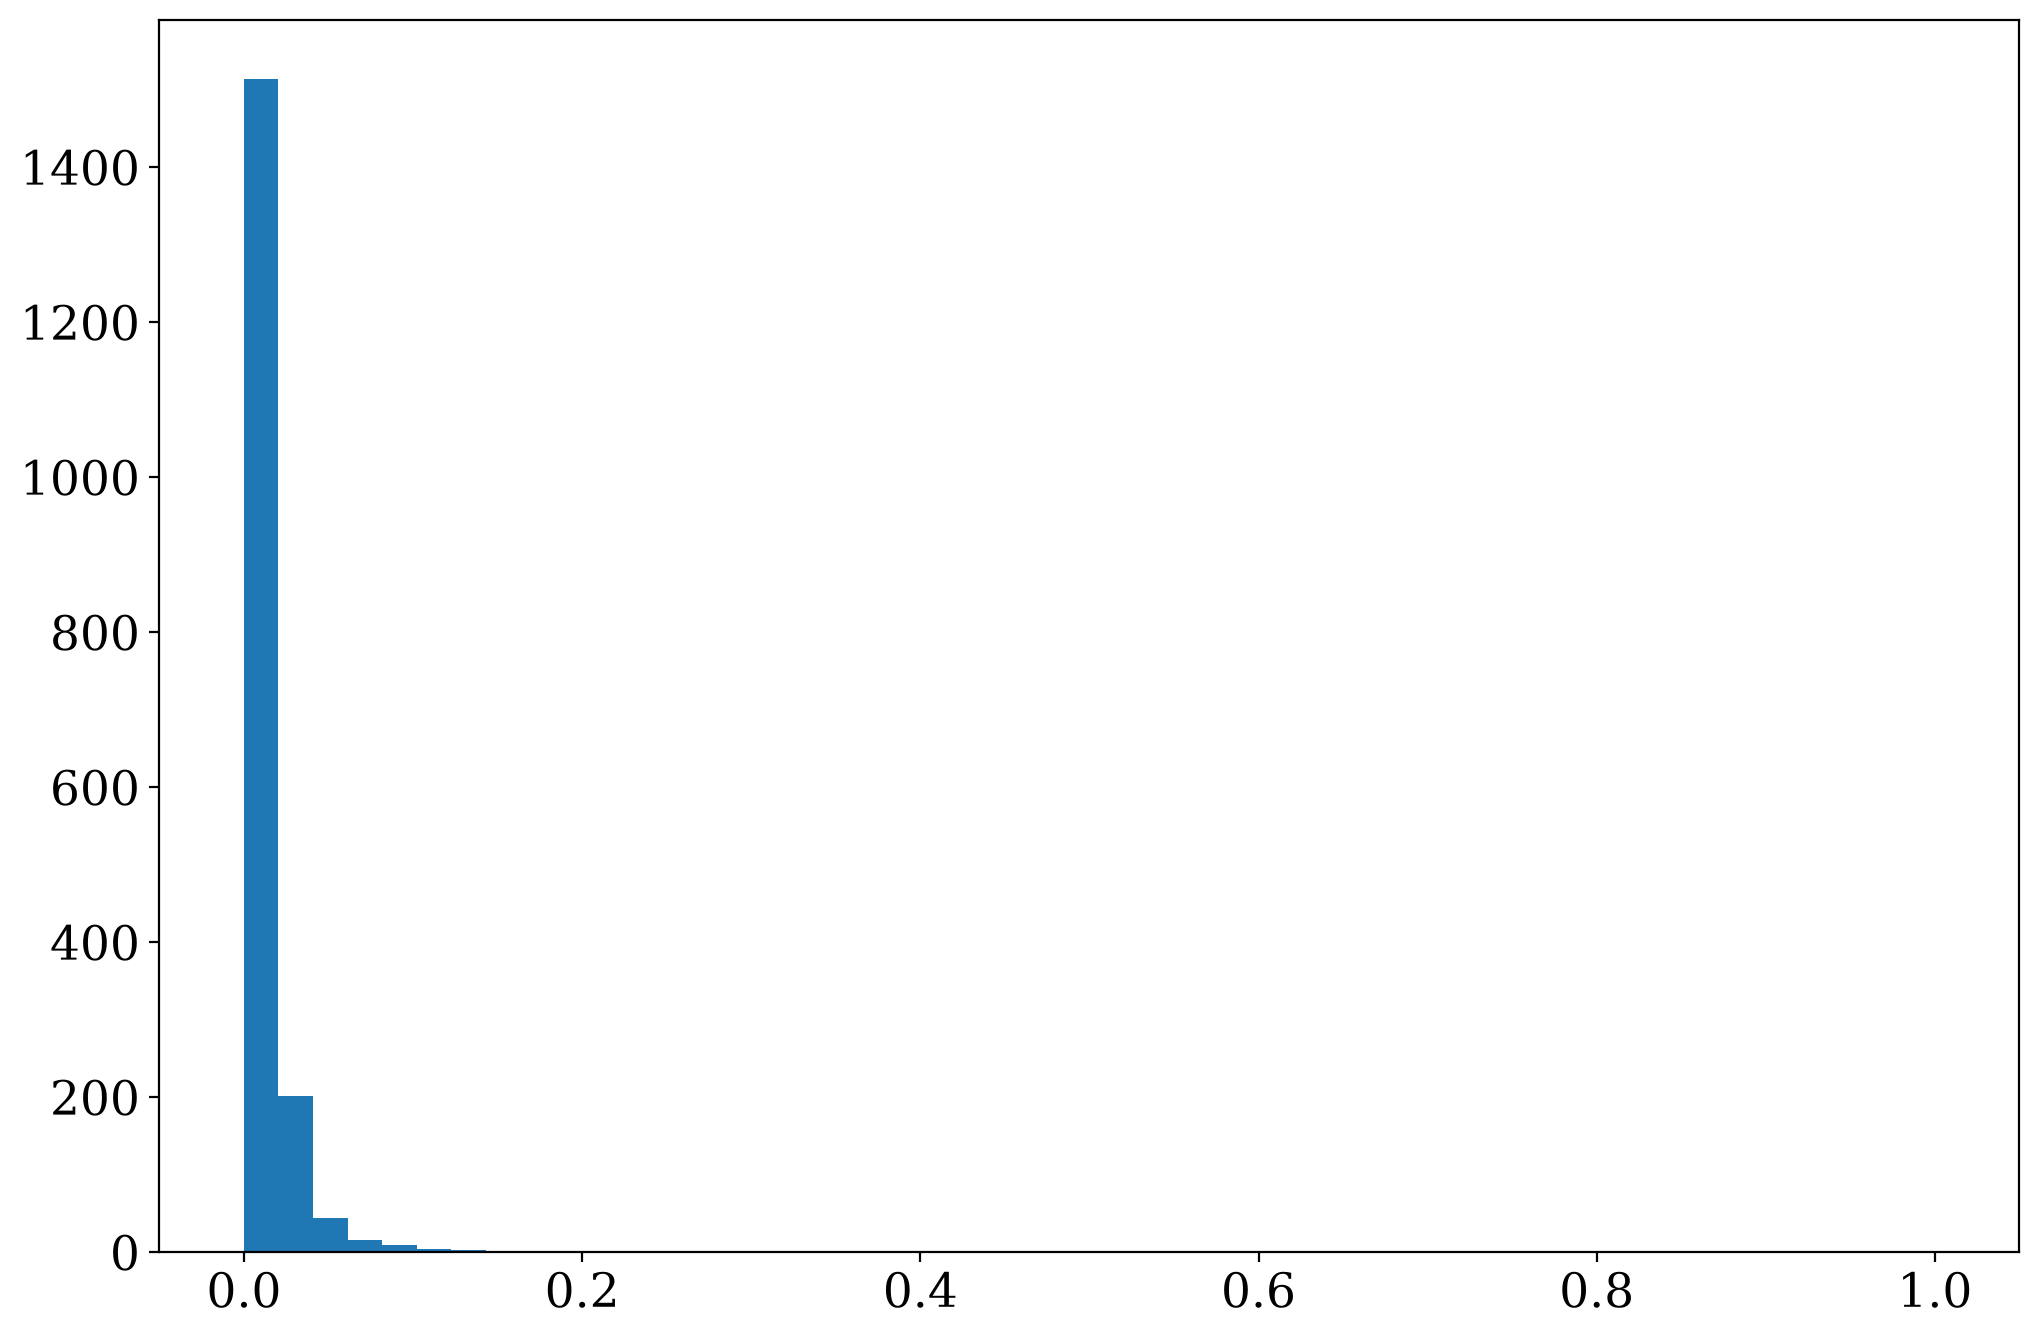

In [129]:
plt.hist(sources.ecc, weights=pop.initC["weights"], bins=np.linspace(0, 1, 50))

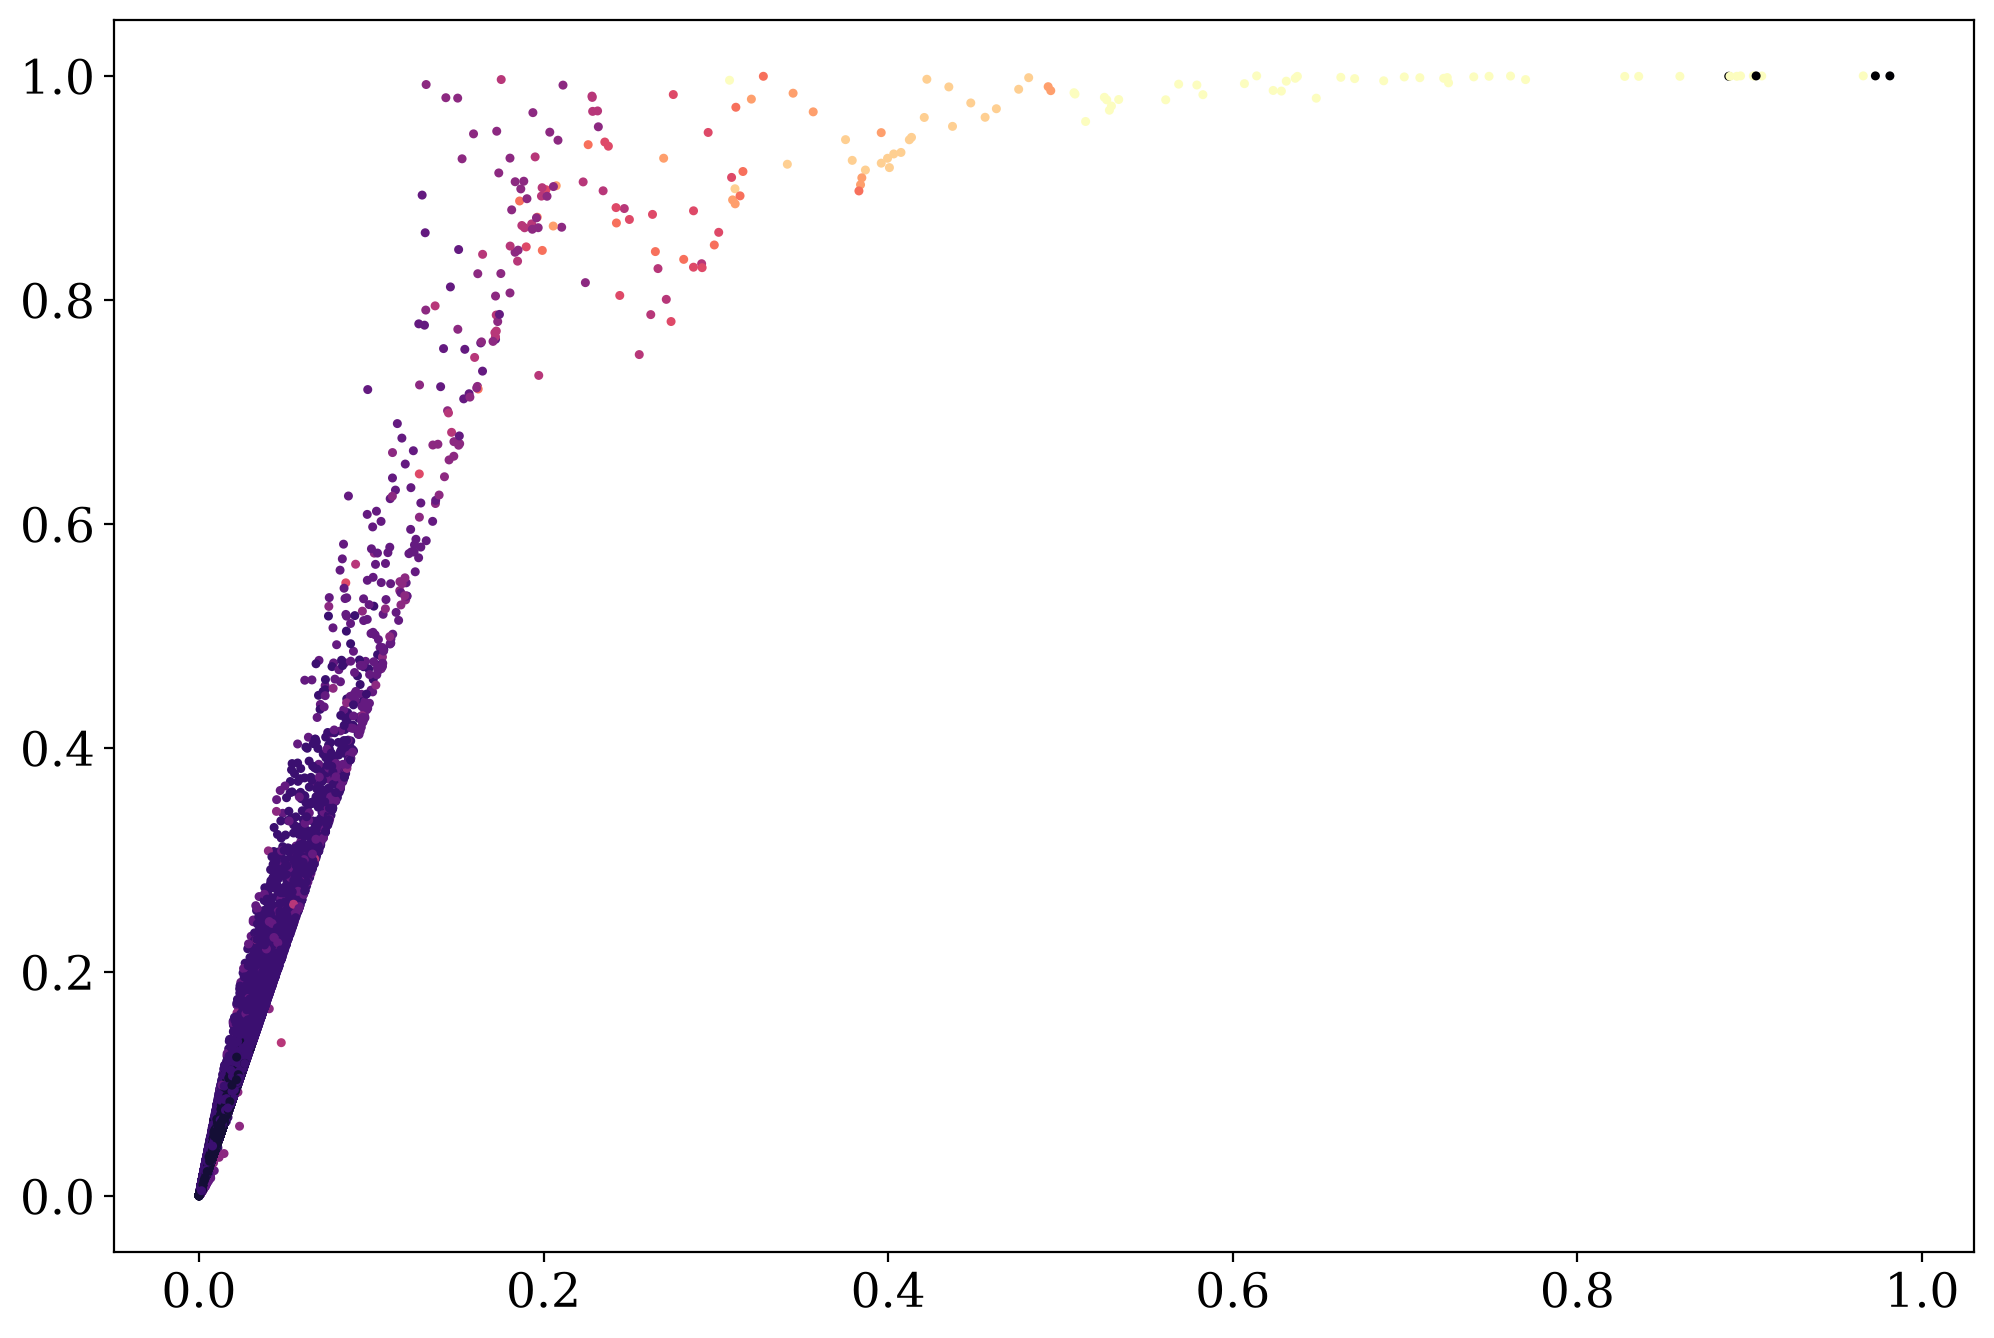

In [125]:
plt.scatter(sources.ecc, p_ecc, c=detectable_harmonics, vmin=0, vmax=10, cmap="magma", s=5)

(array([2.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 2.000e+00, 2.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 4.000e+00,
        3.000e+00, 1.000e+00, 0.000e+00, 1.000e+00, 6.000e+00, 3.000e+00,
        5.000e+00, 7.000e+00, 3.000e+00, 2.000e+00, 3.000e+00, 1.200e+01,
        1.000e+01, 9.000e+00, 1.200e+01, 1.400e+01, 1.100e+01, 2.600e+01,
        2.200e+01, 1.900e+01, 2.100e+01, 2.300e+01, 3.300e+01, 2.100e+01,
        3.300e+01, 4.400e+01, 3.300e+01, 3.500e+01, 5.000e+01, 5.000e+01,
        6.700e+01, 7.200e+01, 6.500e+01, 8.100e+01, 7.500e+01, 8.200e+01,
        8.600e+01, 1.010e+02, 1.260e+02, 1.210e+02, 1.300e+02, 1.350e+02,
        1.710e+02, 1.810e+02, 1.880e+02, 2.020e+02, 2.350e+02, 2.630e+02,
        2.920e+02, 3.150e+02, 3.700e+02, 3.810e+02, 4.480e+02, 4.490e+02,
        4.900e+02, 5.690e+02, 5.390e+02, 6.110e+02, 6.500e+02, 6.400e+02,
        8.030e+02, 8.280e+02, 8.940e+0

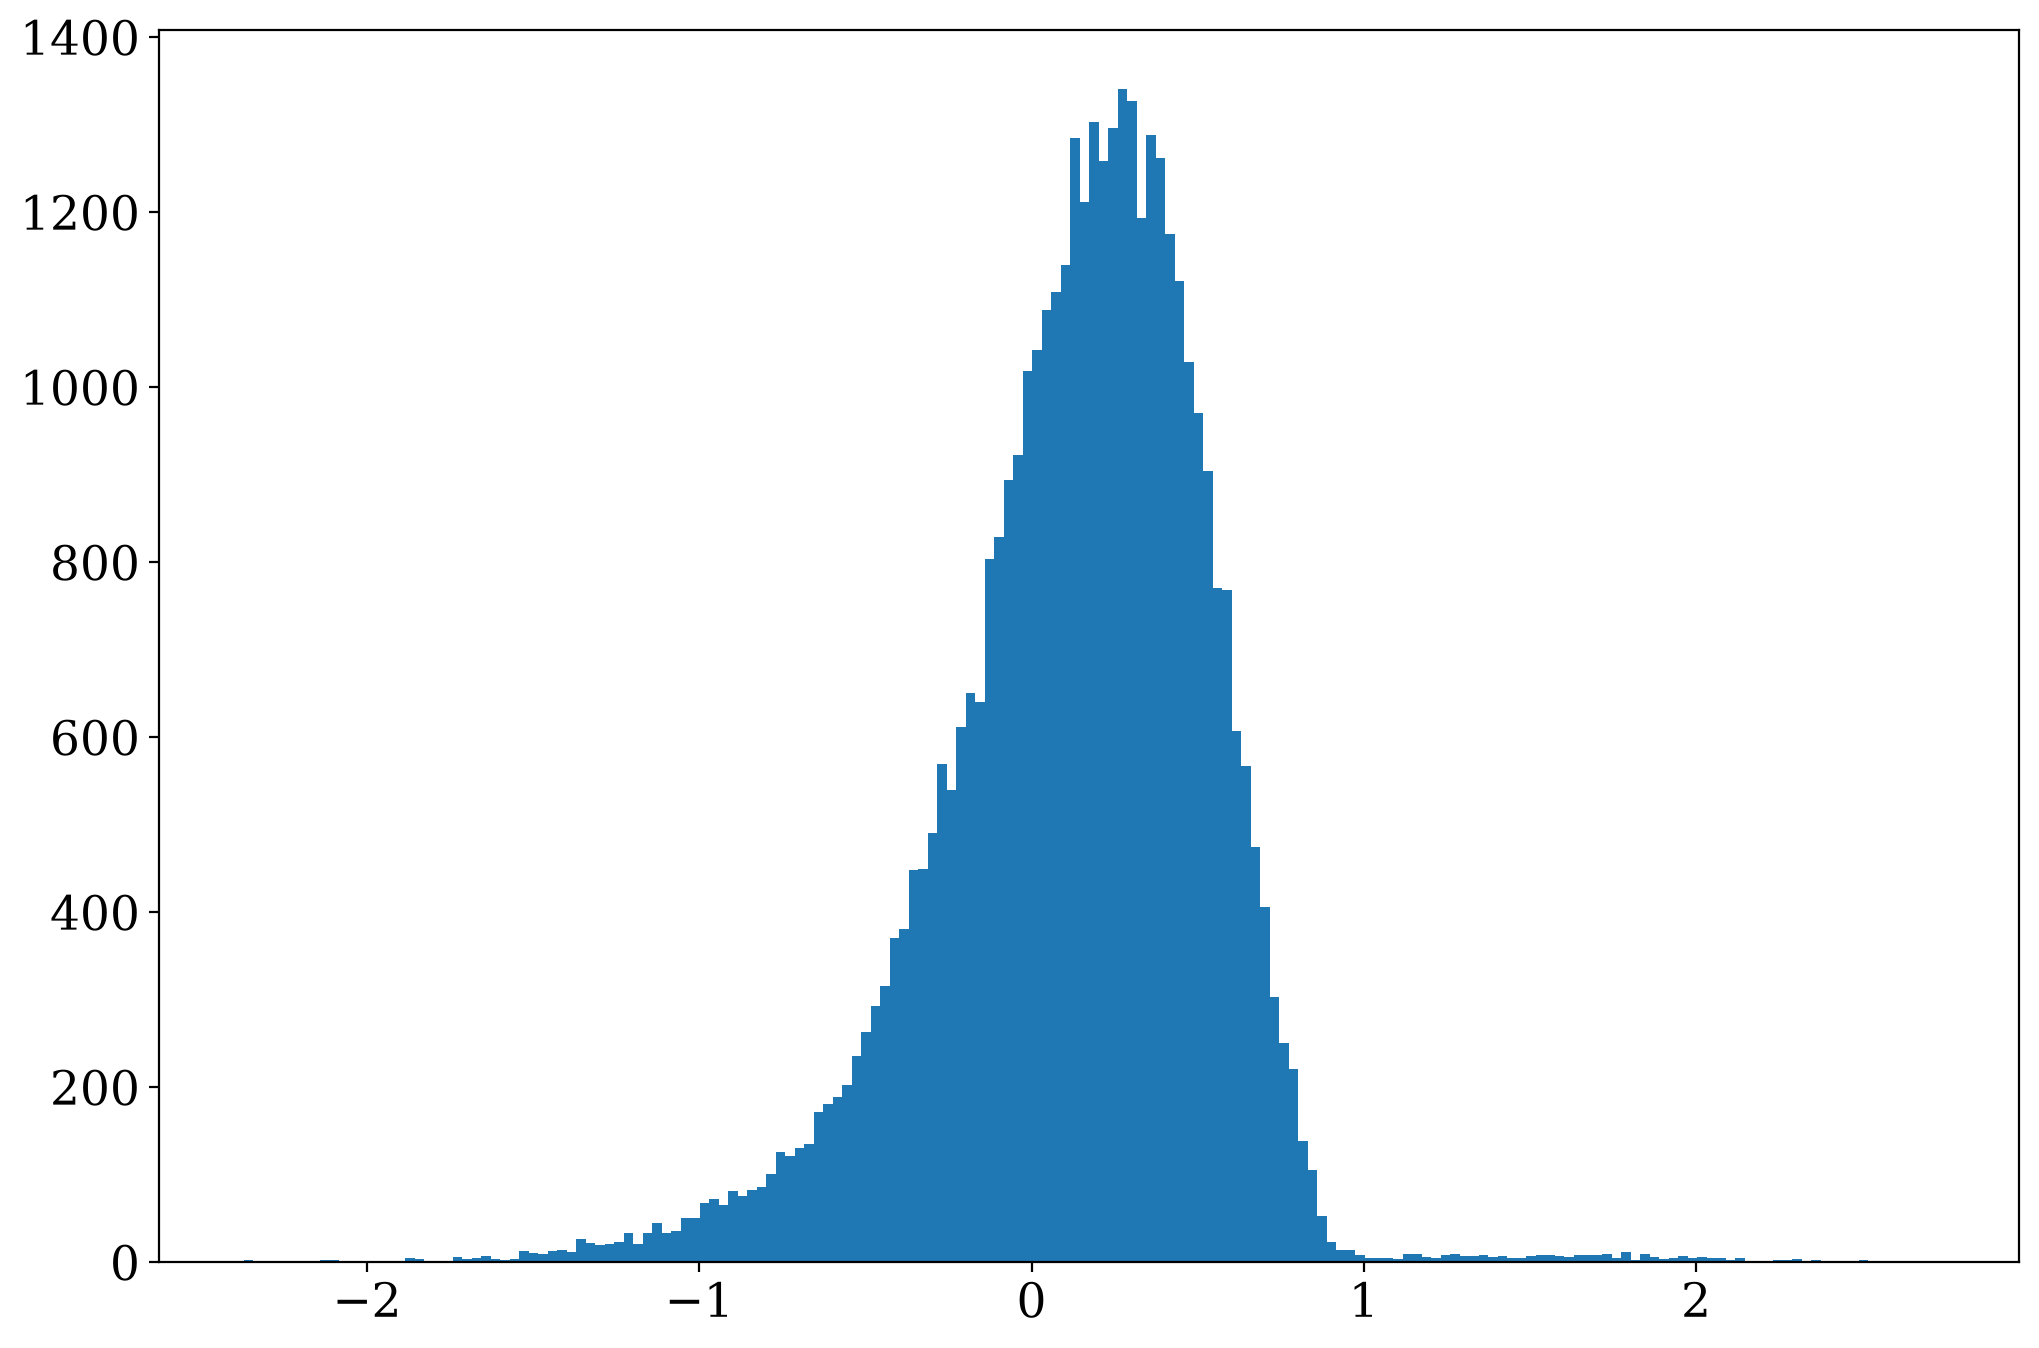

In [104]:
plt.hist(np.log10(ecc_uncertainty), bins="auto")

In [114]:
def estimate_scale_height_cdf(
        z, plot=False, fig=None, ax=None, show=True,
        label="", colour="black", scale_height_loc=None,
        R=None, Rlims=(7.5, 8.5), verbose=False, weight_bins=False, lw=4, zorder=1, **kwargs):
    """Estimate the scale height of a distribution given z-positions using the cumulative distribution function (CDF).
    This method does not assume a model, but instead just finds the z-value at which the CDF reaches 1 - 1/e ~ 0.63, which corresponds to the scale height for an exponential distribution."""
    z = np.abs(z)
    if R is not None:
        R = R.to(u.kpc).value if hasattr(R, 'unit') else R
        mask = (R >= Rlims[0]) & (R < Rlims[1])
        if verbose:
            print(len(z), "objects before Rlims")
        z = z[mask]
        if verbose:
            print(len(z), "objects in Rlims")

    if hasattr(z, 'unit'):
        z = z.to(u.kpc).value

    # calculate empirical CDF without any binning
    sorted_z = np.sort(z)
    cdf = np.arange(1, len(sorted_z) + 1) / len(sorted_z)

    scale_height = sorted_z[cdf >= (1 - 1 / np.e)][0]


    if plot:
        if fig is None or ax is None:
            fig, ax = plt.subplots()

        # interpolate cdf for plotting
        subsample_z = np.geomspace(sorted_z.min(), sorted_z.max(), 1000)
        cdf_interp = np.interp(subsample_z, sorted_z, cdf)

        ax.plot(subsample_z, cdf_interp, label=label, color=colour, lw=lw, zorder=zorder)

        if scale_height_loc is not None:
            loc = 0.5 if scale_height_loc is None else scale_height_loc
            ax.axvline(scale_height, color=colour, ls='--', alpha=0.75, lw=lw/2)
            ax.annotate(f"{scale_height * 1000:.0f} pc", xy=(scale_height, loc), fontsize=16,
                        rotation=0, color=colour, ha='center', va='top',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colour, lw=lw/2))

        ax.set(
            xlabel="Distance from the Galactic plane, |z| (kpc)",
            ylabel=kwargs.pop('ylabel', r'$F(z)$'),
            xscale=kwargs.pop('xscale', 'log'),
            **kwargs
        )
        ax.set_xlabel(ax.get_xlabel(), fontsize=18)
        ax.legend(fontsize=16)

        if show:
            plt.show()

        return scale_height, None, fig, ax
    else:
        return scale_height, None, None, None

In [127]:
np.sum(pop.initC["weights"][(np.abs(pop.final_pos[:, 2]) > 10 * u.kpc)]) / np.sum(pop.initC["weights"])

np.float64(0.012693874278977724)

In [128]:
np.sum(pop.initC["weights"][(np.abs(pop.initial_galaxy.z) > 10 * u.kpc)]) / np.sum(pop.initC["weights"])

np.float64(0.0)

/tmp/ipykernel_1209086/4266997424.py:51: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=16)



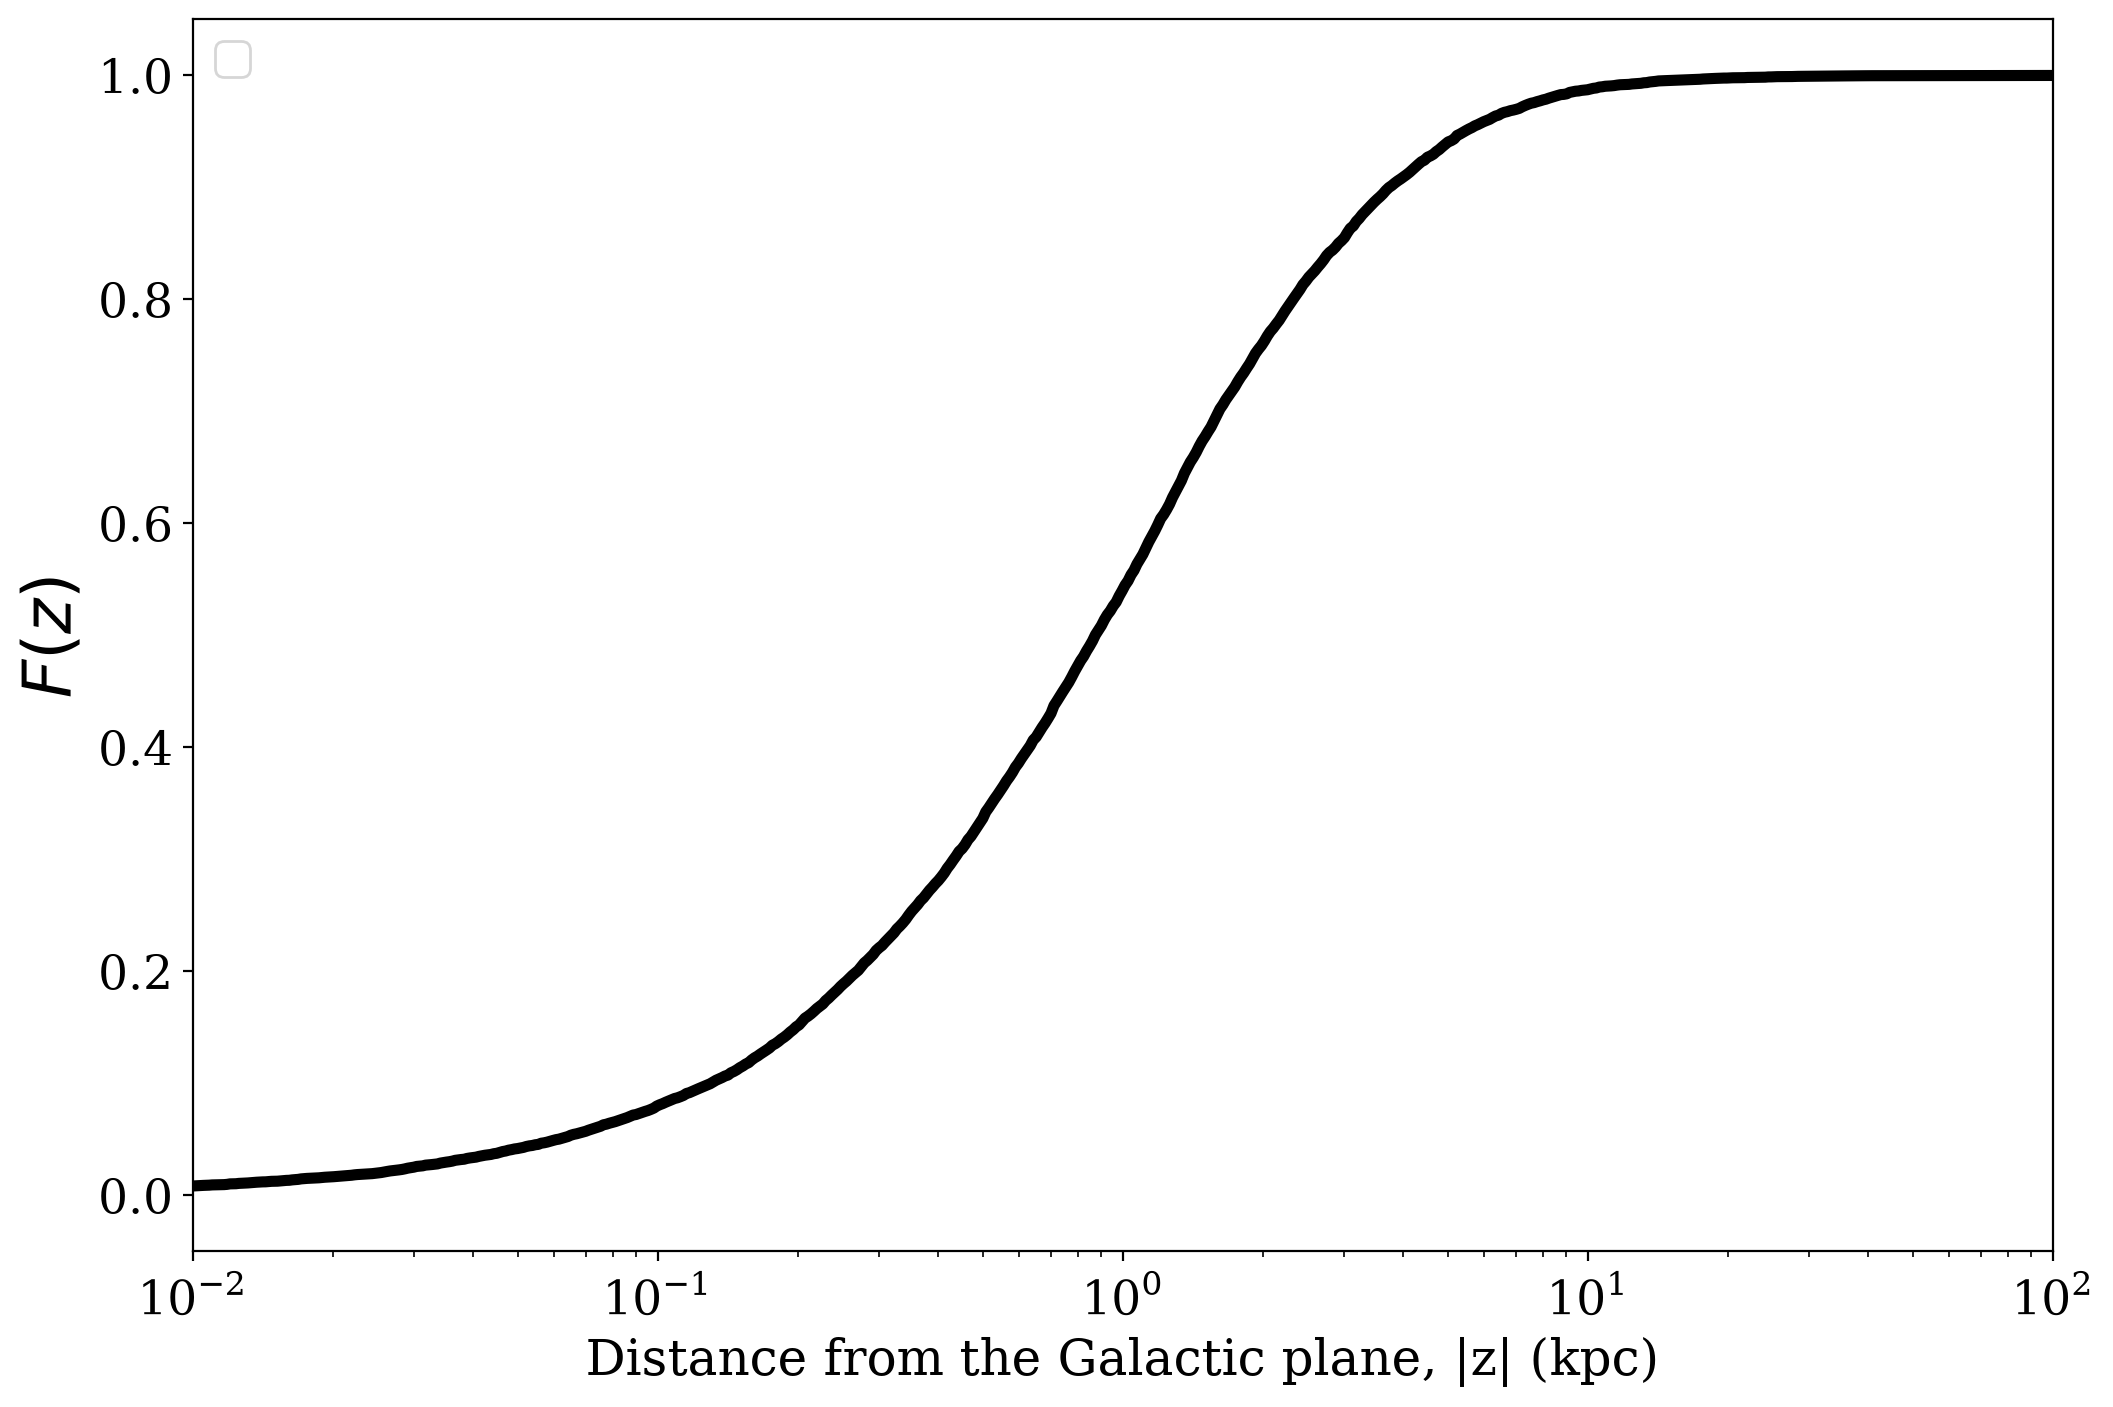

(np.float64(1.3142811925336093), None, <Figure size 1200x800 with 1 Axes>, <Axes: xlabel='Distance from the Galactic plane, |z| (kpc)', ylabel='$F(z)$'>)


In [122]:
weighted_z = np.random.choice(pop.final_pos[:, 2], size=50000, p=pop.initC["weights"] / np.sum(pop.initC["weights"]), replace=True)
print(estimate_scale_height_cdf(weighted_z, plot=True, xlim=(1e-2, 1e2)))

In [2]:
fiducial = {'xi': 1.0, 'bhflag': 1, 'neta': 0.5, 'windflag': 3, 'wdflag': 1, 'alpha1': 1.0, 
            'pts1': 0.001, 'pts3': 0.02, 'pts2': 0.01, 'epsnov': 0.001, 'hewind': 0.5, 
            'ck': 1000, 'bwind': 0.0, 'lambdaf': 0.0, 'mxns': 3.0, 'beta': -1.0,
            'tflag': 1, 'acc2': 1.5, 'grflag' : 1, 'remnantflag': 4, 'ceflag': 0, 
            'eddfac': 1.0, 'ifflag': 0, 'bconst': 3000, 'sigma': 265.0, 'gamma': -2.0, 
            'pisn': 45.0, 'natal_kick_array' : [[-100.0,-100.0,-100.0,-100.0,0.0], [-100.0,-100.0,-100.0,-100.0,0.0]], 
            'bhsigmafrac' : 1.0, 'polar_kick_angle' : 90, 
            'qcrit_array' : [0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0],
            'cekickflag' : 2, 'cehestarflag' : 0, 'cemergeflag' : 0, 'ecsn' : 2.5, 
            'ecsn_mlow' : 1.8, 'aic' : 1, 'ussn' : 0, 'sigmadiv' :-20.0, 'qcflag' : 5,
            'eddlimflag' : 0, 
            'fprimc_array' : [2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0,2.0/21.0],
            'bhspinflag' : 0, 'bhspinmag' : 0.0, 'rejuv_fac' : 1.0, 'rejuvflag' : 0, 
            'htpmb' : 1, 'ST_cr' : 1, 'ST_tide' : 1,
            'bdecayfac' : 1, 'rembar_massloss' : 0.5, 'kickflag' : 5, 'zsun' : 0.014, 
            'bhms_coll_flag' : 0, 'don_lim' : -1,
            'acc_lim' : -1, 'rtmsflag' : 0, 'wd_mass_lim': 1}

In [3]:
BSEDict = cosmic.utils.parse_inifile("../src/params.ini")[0]

In [7]:
for k in fiducial:
    if fiducial[k] != BSEDict[k]:
        print(f"Parameter {k} differs")
        print(f"   Frank={fiducial[k]}, Tom={BSEDict[k]}")

Parameter xi differs
   Frank=1.0, Tom=0.5
Parameter bhflag differs
   Frank=1, Tom=4
Parameter alpha1 differs
   Frank=1.0, Tom=[1.0, 1.0]
Parameter beta differs
   Frank=-1.0, Tom=0.125
Parameter ceflag differs
   Frank=0, Tom=1
Parameter eddfac differs
   Frank=1.0, Tom=10
Parameter ifflag differs
   Frank=0, Tom=1
Parameter pisn differs
   Frank=45.0, Tom=-4
Parameter cemergeflag differs
   Frank=0, Tom=1
Parameter ecsn differs
   Frank=2.5, Tom=2.25
Parameter ecsn_mlow differs
   Frank=1.8, Tom=1.6
Parameter ussn differs
   Frank=0, Tom=1
Parameter acc_lim differs
   Frank=-1, Tom=[-1, -1]
